# Destilación Flash Multicomponente: Método de Rachford-Rice

**Autor:** Luis H. Reyes

**Tema:** Resolución del equilibrio flash multicomponente mediante el algoritmo de Rachford-Rice

---

## Objetivos de Aprendizaje

Al completar este notebook, será capaz de:

1. Comprender los fundamentos teóricos de la destilación flash
2. Entender el problema de Rachford-Rice y su formulación matemática
3. Implementar algoritmos numéricos para resolver el sistema
4. Aplicar el método a problemas prácticos multicomponente
5. Interpretar resultados y validar soluciones físicamente
6. Analizar la sensibilidad del sistema a parámetros operacionales

---

## Ficha del taller

| | |
|---|---|
| **Curso** | Proyecto de Operaciones Unitarias · IQYA-2031 · 2026-20 |
| **Modalidad** | En parejas, de libre elección |
| **Sesión** | Jueves 8 de octubre de 2026 |
| **Entrega** | Domingo 11 de octubre, 11:59 p. m., por BloqueNeón |
| **Puntaje** | 100 puntos |
| **Archivo** | `Taller_07_Rachford_Rice_Apellido1_Apellido2.ipynb` |

**Nivel de uso de IA generativa: 2.** La inteligencia artificial se usa para
hacer lluvia de ideas, estructurar el trabajo y orientar la búsqueda de
fuentes. Usted parte de esas sugerencias y desarrolla el trabajo con su propio
juicio. El contenido final debe estar desarrollado por usted. La declaración de
uso va en la última celda del cuaderno.

**Cómo se trabaja.** En la sesión se recorren la teoría y los ejemplos, y se
resuelve completo el ejercicio 0. Los ejercicios 1 a 3 quedan como trabajo
autónomo de la pareja.

**Antes de entregar:** ejecute el cuaderno completo de arriba abajo, con
*Entorno de ejecución, Reiniciar y ejecutar todo*. Un cuaderno sin salidas no
se califica.

---


---

## Tabla de Contenidos

1. [Fundamentos Teóricos](#1-fundamentos-teóricos)
2. [Ecuación de Rachford-Rice](#2-ecuación-de-rachford-rice)
3. [Algoritmo de Solución](#3-algoritmo-de-solución)
4. [Implementación en Python](#4-implementación-en-python)
5. [Ejemplos Prácticos](#5-ejemplos-prácticos)
6. [Análisis de Sensibilidad](#6-análisis-de-sensibilidad)
7. [Ejercicios Propuestos](#7-ejercicios-propuestos)

---

# 1. Fundamentos Teóricos

## 1.1 ¿Qué es la Destilación Flash?

La destilación flash es una operación unitaria donde una corriente líquida a alta presión se introduce en un tambor a menor presión. La caída de presión provoca vaporización parcial instantánea (flash) del líquido.

### ¿Por qué ocurre la vaporización?

Cuando un líquido está a presión elevada, sus moléculas están "comprimidas" y permanecen en fase líquida. Al entrar al tambor flash donde la presión es menor, estas moléculas tienen más espacio y libertad para escapar a la fase vapor. Es como abrir una botella de gaseosa: la caída de presión permite que el CO₂ disuelto escape formando burbujas.

### Características del Proceso

**Condiciones de operación:**
- **Proceso continuo de separación:** La alimentación entra constantemente, el vapor y líquido salen constantemente
- **Una sola etapa de equilibrio:** Vapor y líquido alcanzan equilibrio termodinámico en el tambor
- **Presión y temperatura controladas:** T y P determinan cuánto se vaporiza
- **Equilibrio termodinámico alcanzado:** Las fases vapor y líquido están en equilibrio (no hay transferencia neta de masa entre ellas)

**Variables del sistema:**
- **Composición de alimentación (z₁, z₂, ..., zₙ):** Fracción molar de cada componente en la mezcla que entra
- **Temperatura del tambor (T):** Controla la volatilidad de los componentes (°C o K)
- **Presión del tambor (P):** Determina qué tan fácil es vaporizar (kPa, bar, o atm)
- **Flujo de alimentación (F):** Cantidad de mezcla procesada por unidad de tiempo (kmol/h, kg/h)

### Diagrama del Proceso
```
     Alimentación (F, zᵢ)
            │
            │ T₁, P₁ (alta presión)
            ▼
      ┌──────────┐
      │          │◄─── Calor (Q) [opcional]
      │  TAMBOR  │
      │  FLASH   │      T, P (baja presión)
      │          │
      └──────────┘
         │    │
         │    │
    Vapor│    │Líquido
    (V,yᵢ)   (L,xᵢ)
```

**Explicación del diagrama:**
- La alimentación entra como líquido a presión alta (P₁)
- Al entrar al tambor, la presión baja (P < P₁) causando vaporización
- Los componentes más volátiles (K > 1) tienden a ir al vapor
- Los componentes menos volátiles (K < 1) permanecen más en el líquido
- Se puede agregar o quitar calor (Q) para controlar la temperatura

## 1.2 Ecuaciones Fundamentales

### Balance de Materia Global

**El principio:** Lo que entra debe salir (conservación de la masa).

El balance de materia total establece:

$$F = V + L$$

Donde:
- **F** = flujo molar de alimentación (kmol/h) → lo que entra
- **V** = flujo molar de vapor (kmol/h) → lo que sale como gas
- **L** = flujo molar de líquido (kmol/h) → lo que sale como líquido

**Ejemplo numérico:** Si alimentamos F = 100 kmol/h, y se forman V = 40 kmol/h de vapor, entonces:
L = F - V = 100 - 40 = 60 kmol/h de líquido

---

### Balance por Componente

**El principio:** Cada componente individual también se conserva.

Para cada componente i:

$$F \cdot z_i = V \cdot y_i + L \cdot x_i$$

Donde:
- **zᵢ** = fracción molar del componente i en la alimentación (adimensional, 0 ≤ zᵢ ≤ 1)
- **yᵢ** = fracción molar del componente i en el vapor (adimensional, 0 ≤ yᵢ ≤ 1)
- **xᵢ** = fracción molar del componente i en el líquido (adimensional, 0 ≤ xᵢ ≤ 1)

**Interpretación física:**
- El lado izquierdo (F·zᵢ) es cuántos moles del componente i entran
- El lado derecho (V·yᵢ + L·xᵢ) es cuántos moles del componente i salen (en vapor + en líquido)
- Estos deben ser iguales (lo que entra = lo que sale)

**Ejemplo numérico:** Si tenemos propano (i = 1) con:
- F = 100 kmol/h, z₁ = 0.3 (30% propano en alimentación)
- V = 40 kmol/h, y₁ = 0.6 (60% propano en vapor)
- L = 60 kmol/h, x₁ = 0.1 (10% propano en líquido)

Verificación: F·z₁ = 100(0.3) = 30 kmol/h
V·y₁ + L·x₁ = 40(0.6) + 60(0.1) = 24 + 6 = 30 kmol/h 

---

### Equilibrio Termodinámico

**El concepto:** En equilibrio, existe una relación entre la composición del vapor y del líquido para cada componente.

La relación de equilibrio se expresa mediante la **constante de equilibrio K**:

$$K_i = \frac{y_i}{x_i}$$

**¿Qué significa Kᵢ?**

- **Kᵢ > 1:** El componente es más **volátil** (prefiere estar en el vapor). Ejemplo: propano en una mezcla con pentano
- **Kᵢ = 1:** El componente se distribuye por igual entre vapor y líquido
- **Kᵢ < 1:** El componente es menos **volátil** (prefiere estar en el líquido). Ejemplo: pentano en una mezcla con propano

**Ejemplo numérico:** Si $K_{propano}$ = 2.5 y $x_{propano}$ = 0.1, entonces:
$y_{propano}$ = $K_{propano}$ × $x_{propano}$ = 2.5 × 0.1 = 0.25

Esto significa que el propano se concentra 2.5 veces más en el vapor que en el líquido.

---

### ¿De qué depende Kᵢ?

Esta constante depende de:
- **Temperatura del sistema (T):** A mayor T, generalmente Kᵢ aumenta (más vaporización)
- **Presión del sistema (P):** A menor P, generalmente Kᵢ aumenta (más fácil vaporizar)
- **Composición de las fases:** En sistemas no ideales, Kᵢ también depende de xᵢ y yᵢ
- **Propiedades del componente:** Cada sustancia tiene diferente volatilidad

**En este notebook:** Asumimos que las constantes K son conocidas (dadas o calculadas con modelos termodinámicos). En la práctica, se obtienen de:
- Ecuaciones de estado (Peng-Robinson, Soave-Redlich-Kwong)
- Modelos de actividad (NRTL, UNIQUAC, Wilson)
- Correlaciones empíricas
- Datos experimentales

---

### Restricciones de Composición

**Restricción física fundamental:** Las fracciones molares siempre deben sumar 1 (100%).

Para el líquido:
$$\sum_{i=1}^{n} x_i = 1$$

Para el vapor:
$$\sum_{i=1}^{n} y_i = 1$$

**¿Por qué?** Las fracciones molares representan "partes del total". Si tienes 3 componentes con x₁=0.5, x₂=0.3, x₃=0.2, entonces:
x₁ + x₂ + x₃ = 0.5 + 0.3 + 0.2 = 1.0 (representan el 100% del líquido)

**Validación importante:** Después de resolver el problema flash, SIEMPRE verificar que estas sumas den 1.0 (o muy cercano, como 0.9999 o 1.0001 por errores numéricos).

## 1.3 Fracción Vaporizada (β)

Un parámetro clave es la **fracción vaporizada** o **fracción de vapor**:

$$\beta = \frac{V}{F}$$

### ¿Qué significa β?

Esta variable representa **qué porción de la alimentación se vaporiza**. Es la respuesta a la pregunta: "¿Qué porcentaje de lo que entra sale como vapor?"

**Valores posibles de β:**

- **β = 0:** Todo permanece líquido, no hay vaporización (V = 0, L = F)
  - Ocurre cuando: T es muy baja o P es muy alta
  - Físicamente: Las condiciones no permiten formar vapor
  
- **0 < β < 1:** Separación flash típica, coexisten dos fases (V > 0 y L > 0)
  - Ocurre cuando: Las condiciones T y P permiten equilibrio vapor-líquido
  - Físicamente: Parte de la mezcla se vaporiza, parte permanece líquida
  
- **β = 1:** Todo se vaporiza, no hay líquido (V = F, L = 0)
  - Ocurre cuando: T es muy alta o P es muy baja
  - Físicamente: Las condiciones favorecen completamente la vaporización

---

### Relación con los Flujos

Podemos expresar los flujos en términos de β:

$$V = \beta \cdot F$$

$$L = (1 - \beta) \cdot F$$

**Ejemplos numéricos:**

| F (kmol/h) | β | V (kmol/h) | L (kmol/h) | Interpretación |
|------------|---|------------|------------|----------------|
| 100 | 0.0 | 0 | 100 | Todo líquido |
| 100 | 0.25 | 25 | 75 | 25% se vaporiza |
| 100 | 0.50 | 50 | 50 | Mitad vapor, mitad líquido |
| 100 | 0.75 | 75 | 25 | 75% se vaporiza |
| 100 | 1.0 | 100 | 0 | Todo vapor |

---

### ¿Por qué β es importante?

**β es la incógnita principal del problema de Rachford-Rice.**

Una vez conocemos β, podemos calcular:
1. Los flujos V y L usando las ecuaciones arriba
2. Las composiciones xᵢ y yᵢ usando las ecuaciones que derivaremos en la Sección 2

**En resumen:** Resolver el problema flash = encontrar el valor correcto de β

---

# 2. Ecuación de Rachford-Rice

## 2.1 Deducción de la Ecuación

**Objetivo de esta sección:** Derivar una ecuación que nos permita calcular β (fracción vaporizada) conociendo solo la composición de alimentación (z) y las constantes de equilibrio (K).

---

### Paso 1: Balance por Componente

Partimos del balance de materia para el componente i:

$$F \cdot z_i = V \cdot y_i + L \cdot x_i$$

**Dividiendo entre F** (para trabajar con fracciones):

$$z_i = \frac{V}{F} \cdot y_i + \frac{L}{F} \cdot x_i$$

**Sustituyendo las definiciones de β:**

Recordemos que β = V/F y por lo tanto (1-β) = L/F

$$z_i = \beta \cdot y_i + (1-\beta) \cdot x_i$$

**Interpretación:** Esta ecuación dice que la fracción molar en la alimentación (zᵢ) es un promedio ponderado entre la fracción en el vapor (yᵢ) y en el líquido (xᵢ), donde los pesos son β y (1-β).

---

### Paso 2: Introducir el Equilibrio

Usamos la relación de equilibrio termodinámico:

$$y_i = K_i \cdot x_i$$

**Sustituyendo en el balance:**

$$z_i = \beta \cdot (K_i \cdot x_i) + (1-\beta) \cdot x_i$$

**¿Por qué hacemos esto?** Porque queremos expresar todo en términos de xᵢ (o yᵢ), para después poder eliminar estas variables y quedarnos solo con β.

---

### Paso 3: Despejar xᵢ

**Factorizando xᵢ:**

$$z_i = x_i [\beta \cdot K_i + (1-\beta)]$$

**Expandiendo el término entre corchetes:**

$$z_i = x_i [\beta \cdot K_i + 1 - \beta]$$

$$z_i = x_i [1 + \beta \cdot K_i - \beta]$$

$$z_i = x_i [1 + \beta(K_i - 1)]$$

**Despejando xᵢ:**

$$\boxed{x_i = \frac{z_i}{1 + \beta(K_i - 1)}}$$

**Esta es una ecuación fundamental:** Nos dice cómo calcular la composición del líquido (xᵢ) en función de la alimentación (zᵢ), la constante de equilibrio (Kᵢ), y la fracción vaporizada (β).

---

### Paso 4: Expresar yᵢ

Usando la relación de equilibrio yᵢ = Kᵢ·xᵢ:

$$y_i = K_i \cdot x_i = K_i \cdot \frac{z_i}{1 + \beta(K_i - 1)}$$

$$\boxed{y_i = \frac{K_i \cdot z_i}{1 + \beta(K_i - 1)}}$$

**Esta es la ecuación complementaria:** Nos permite calcular la composición del vapor (yᵢ) usando las mismas variables.

---

### Resumen de las Ecuaciones Clave

Tenemos dos ecuaciones fundamentales:

1. **Composición del líquido:** $x_i = \dfrac{z_i}{1 + \beta(K_i - 1)}$

2. **Composición del vapor:** $y_i = \dfrac{K_i \cdot z_i}{1 + \beta(K_i - 1)}$

**Nota:** Ambas dependen de β, que aún no conocemos. Ahora necesitamos una ecuación para calcular β.

## 2.2 La Función de Rachford-Rice

### Formulación del Problema

**La restricción que falta:** Sabemos que las fracciones molares en el vapor deben sumar 1:

$$\sum_{i=1}^{n} y_i = 1$$

**¿Por qué usamos esta restricción?** Porque yᵢ son fracciones: representan "partes de un todo", y ese todo debe ser 100% (o 1.0 en decimal).

**Sustituyendo la expresión de yᵢ:**

$$\sum_{i=1}^{n} \frac{K_i \cdot z_i}{1 + \beta(K_i - 1)} = 1$$

**Esto es una ecuación en β:** Contiene solo una incógnita (β), porque zᵢ y Kᵢ son conocidos.

---

### La Ecuación de Rachford-Rice

**Restando 1 de ambos lados**, obtenemos la función característica:

$$f(\beta) = \sum_{i=1}^{n} \frac{K_i \cdot z_i}{1 + \beta(K_i - 1)} - 1 = 0$$

**Forma alternativa usando xᵢ** (sumando todas las xᵢ):

$$g(\beta) = \sum_{i=1}^{n} \frac{z_i}{1 + \beta(K_i - 1)} - 1 = 0$$

**La forma más común (factorizando):**

$$\boxed{f(\beta) = \sum_{i=1}^{n} \frac{z_i(K_i - 1)}{1 + \beta(K_i - 1)} = 0}$$

---

### ¿Qué significa esta ecuación?

**Esta es la ecuación de Rachford-Rice:** Una ecuación no lineal en β que debemos resolver numéricamente.

**Interpretación física:**
- Cuando β tiene el valor correcto, la ecuación se cumple: f(β) = 0
- Si β es muy pequeño (poco vapor), f(β) > 0
- Si β es muy grande (mucho vapor), f(β) < 0
- Nuestra tarea: encontrar el β que hace f(β) = 0

**Ejemplo conceptual:** Imagine que β = 0.3. Sustituimos en la ecuación y calculamos f(0.3). Si obtenemos f(0.3) = 0.05, significa que β = 0.3 es muy pequeño. Si obtenemos f(0.3) = -0.03, significa que β = 0.3 es muy grande. Queremos encontrar el β donde f(β) = 0 (o muy cercano a cero, como 0.0000001).

---

### ¿Por qué se llama Rachford-Rice?

Esta ecuación fue desarrollada por **H.H. Rachford Jr. y J.D. Rice en 1952** para resolver problemas de equilibrio flash en la industria petrolera. Su método revolucionó los cálculos de separación porque permite calcular β directamente sin necesidad de iteraciones anidadas.

## 2.3 Propiedades de la Función

**¿Por qué estudiar las propiedades de f(β)?** Porque entender el comportamiento de la función nos ayuda a:
1. Saber cuándo existe solución
2. Garantizar convergencia de métodos numéricos
3. Interpretar físicamente los resultados

---

### Límites de la Función

**Evaluemos la función en los extremos del intervalo físico:**

#### Cuando β → 0 (todo líquido):

$$f(0) = \sum_{i=1}^{n} \frac{z_i(K_i - 1)}{1 + 0 \cdot (K_i - 1)} = \sum_{i=1}^{n} z_i(K_i - 1)$$

Expandiendo:
$$f(0) = \sum_{i=1}^{n} z_i K_i - \sum_{i=1}^{n} z_i = \sum_{i=1}^{n} z_i K_i - 1$$

**Interpretación:** f(0) nos dice si la mezcla puede permanecer completamente líquida. Si f(0) > 0, la mezcla "quiere" vaporizarse parcialmente.

#### Cuando β → 1 (todo vapor):

$$f(1) = \sum_{i=1}^{n} \frac{z_i(K_i - 1)}{1 + 1 \cdot (K_i - 1)} = \sum_{i=1}^{n} \frac{z_i(K_i - 1)}{K_i}$$

Simplificando:
$$f(1) = \sum_{i=1}^{n} z_i \left(1 - \frac{1}{K_i}\right) = 1 - \sum_{i=1}^{n} \frac{z_i}{K_i}$$

**Interpretación:** f(1) nos dice si la mezcla puede vaporizarse completamente. Si f(1) < 0, la mezcla "quiere" condensar parcialmente.

---

### Condiciones para Solución

Para que exista una solución física (0 < β < 1), **debe haber cambio de signo en el intervalo [0,1]**:

$$f(0) > 0 \quad \text{y} \quad f(1) < 0$$

**¿Por qué?** Si la función es continua y cambia de signo, por el teorema del valor intermedio, debe cruzar el eje x en algún punto → ahí está nuestra solución.

**Esto se traduce en las condiciones matemáticas:**

$$\sum_{i=1}^{n} z_i K_i > 1 \quad \text{y} \quad \sum_{i=1}^{n} \frac{z_i}{K_i} > 1$$

**Interpretación física:**

- **Primera condición:** Σ(zᵢKᵢ) > 1 significa "la mezcla es suficientemente volátil para formar vapor"
- **Segunda condición:** Σ(zᵢ/Kᵢ) > 1 significa "la mezcla tiene componentes suficientemente pesados para formar líquido"
- **Ambas juntas:** Garantizan que habrá dos fases en equilibrio

**¿Qué pasa si no se cumplen?**
- Si Σ(zᵢKᵢ) ≤ 1: β = 0 (todo líquido, no hay vapor)
- Si Σ(zᵢ/Kᵢ) ≤ 1: β = 1 (todo vapor, no hay líquido)

---

### Comportamiento de la Función

La función f(β) tiene propiedades matemáticas importantes:

1. **Monótona decreciente en (0, 1):** La función siempre baja cuando β aumenta
   - f'(β) < 0 para todo β en (0,1)
   - No hay máximos ni mínimos locales
   - La función cruza el eje x solo una vez

2. **Tiene singularidades (polos):** En puntos donde el denominador es cero:
   - Ocurre cuando: 1 + β(Kᵢ - 1) = 0
   - Esto sucede en: β = -1/(Kᵢ - 1)
   - Para Kᵢ < 1, estos polos están en β > 1 (fuera del rango físico)
   - Para Kᵢ > 1, los polos están en β < 0 (fuera del rango físico)
   - **Conclusión:** Los polos no afectan el intervalo físico [0, 1]

3. **Única raíz en el intervalo físico:** Como f(β) es monótona decreciente y continua en (0,1), solo puede cruzar el eje x una vez
   - **Garantía matemática:** La solución es única
   - **Ventaja numérica:** Cualquier método de búsqueda encontrará la misma solución

4. **Derivada siempre negativa:** Veremos esto en la siguiente sección

**Gráfica conceptual de f(β):**
```
f(β)
  │
  │ f(0) > 0
  │   ╲
  │     ╲
  │       ╲
──┼─────────●───── β (fracción vaporizada)
0 │           ╲  1
  │             ╲ f(1) < 0
  │
```
La función empieza positiva en β=0, cruza el eje en algún punto (esa es nuestra solución), y termina negativa en β=1.

## 2.4 Derivada de la Función (para Newton-Raphson)

**¿Por qué necesitamos la derivada?** El método de Newton-Raphson usa la pendiente de la función para acelerar la convergencia. Es el método numérico más rápido para resolver Rachford-Rice.

---

### Cálculo de la Derivada

Queremos derivar:

$$f(\beta) = \sum_{i=1}^{n} \frac{z_i(K_i - 1)}{1 + \beta(K_i - 1)}$$

**Para cada término de la suma:**

Sea $u_i(\beta) = \dfrac{z_i(K_i - 1)}{1 + \beta(K_i - 1)}$

Podemos escribir como: $u_i = z_i(K_i - 1) \cdot [1 + \beta(K_i - 1)]^{-1}$

**Aplicando la regla de la cadena:**

$$\frac{du_i}{d\beta} = z_i(K_i - 1) \cdot (-1) \cdot [1 + \beta(K_i - 1)]^{-2} \cdot (K_i - 1)$$

$$\frac{du_i}{d\beta} = -z_i(K_i - 1)^2 \cdot [1 + \beta(K_i - 1)]^{-2}$$

**Sumando sobre todos los componentes:**

$$f'(\beta) = \sum_{i=1}^{n} \frac{du_i}{d\beta}$$

$$\boxed{f'(\beta) = -\sum_{i=1}^{n} \frac{z_i(K_i - 1)^2}{[1 + \beta(K_i - 1)]^2}}$$

---

### Propiedades de la Derivada

**Análisis del signo:**

Observemos que:
- $z_i > 0$ (las fracciones molares son positivas)
- $(K_i - 1)^2 > 0$ (cualquier número al cuadrado es positivo)
- $[1 + \beta(K_i - 1)]^2 > 0$ (denominador siempre positivo en el rango físico)
- El signo negativo al frente: $f'(\beta) = -\text{(suma de términos positivos)}$

**Conclusión: f'(β) < 0 para todo β en (0, 1)**

Esto confirma que la función es **monótona decreciente**, lo que garantiza:
1. Única solución en el intervalo físico
2. Convergencia rápida de Newton-Raphson
3. No hay máximos ni mínimos locales

---

### Implementación en Código
```python
def f_derivada(beta, z, K):
    """
    Derivada de la función de Rachford-Rice.
    
    Parámetros:
    - beta: fracción vaporizada
    - z: lista de fracciones molares en alimentación
    - K: lista de constantes de equilibrio
    
    Retorna:
    - f_prima: valor de la derivada en beta
    """
    n = len(z)
    suma = 0.0
    
    for i in range(n):
        numerador = z[i] * (K[i] - 1)**2
        denominador = (1 + beta * (K[i] - 1))**2
        suma += numerador / denominador
    
    f_prima = -suma
    return f_prima
```

**Nota importante:** En Newton-Raphson, usamos tanto f(β) como f'(β) en cada iteración:

$$\beta_{nuevo} = \beta_{actual} - \frac{f(\beta_{actual})}{f'(\beta_{actual})}$$

La derivada nos dice "cuánto está cambiando la función" y nos ayuda a predecir dónde estará la raíz.

---

# 3. Algoritmo de Solución

## 3.1 Métodos Numéricos Disponibles

### Método de Bisección

**Ventajas:**
- Siempre converge si hay cambio de signo
- Robusto y confiable
- Simple de implementar

**Desventajas:**
- Convergencia lenta (lineal)
- Requiere conocer el intervalo inicial

**¿Qué significan a, b y c?**

Estas variables representan valores de la **fracción vaporizada β**:

- **a** = límite inferior del intervalo de búsqueda (inicialmente a = 0, todo líquido)
- **b** = límite superior del intervalo de búsqueda (inicialmente b = 1, todo vapor)  
- **c** = punto medio entre a y b, calculado como c = (a + b) / 2

El método funciona como un juego de "adivina el número": sabemos que β está entre 0 y 1, entonces evaluamos en el punto medio. Dependiendo del signo de f(c), sabemos si la respuesta correcta está en la mitad izquierda o derecha del intervalo. Así vamos reduciendo el intervalo a la mitad en cada iteración.

**Algoritmo:**
```
1. Inicializar el intervalo: a = 0 (todo líquido), b = 1 (todo vapor)
2. Calcular el punto medio: c = (a + b) / 2
3. Evaluar la función en el punto medio: f(c)
4. Determinar dónde está la raíz:
   Si f(a) * f(c) < 0: la raíz está entre a y c → actualizar b = c
   Sino: la raíz está entre c y b → actualizar a = c
5. Repetir hasta que |f(c)| < tolerancia
```

**Interpretación física:** En cada iteración, c representa un "intento" de valor para β. El algoritmo va refinando este intento hasta encontrar el valor que satisface la ecuación de Rachford-Rice.

### Método de Newton-Raphson

**Ventajas:**
- Convergencia muy rápida (cuadrática)
- Pocas iteraciones necesarias

**Desventajas:**
- Requiere calcular la derivada
- Puede diverger con mal punto inicial

**¿Qué significan las variables?**

- **β₀** = valor inicial de la fracción vaporizada (punto de partida, típicamente 0.5)
- **βₙ** = valor de β en la iteración actual (el intento actual)
- **βₙ₊₁** = nuevo valor de β calculado (el próximo intento mejorado)
- **f(βₙ)** = valor de la función de Rachford-Rice evaluada en βₙ
- **f'(βₙ)** = derivada de la función evaluada en βₙ (la pendiente)

El método usa la tangente a la curva en el punto actual para predecir dónde la función cruza el eje x. Es como si trazaras una línea recta que toca la curva en tu punto actual y vieras dónde esa línea cruza el eje horizontal: ese cruce es tu próxima estimación.

**Algoritmo:**
```
1. Inicializar con un valor razonable: β₀ = 0.5 (punto medio)
2. Calcular nuevo valor usando la tangente: βₙ₊₁ = βₙ - f(βₙ) / f'(βₙ)
3. Verificar si ya convergió: |βₙ₊₁ - βₙ| < tolerancia
4. Si no convergió: hacer βₙ = βₙ₊₁ y volver al paso 2
5. Si convergió: la solución es βₙ₊₁
```

**Interpretación geométrica:** En cada iteración, trazamos la línea tangente a f(β) en el punto actual y usamos el cruce de esa tangente con el eje x como nuestra próxima estimación. Por eso converge tan rápido: usa información local (la pendiente) para dar "saltos inteligentes" hacia la solución.

**¿Por qué puede diverger?** Si el punto inicial está mal elegido, la tangente puede apuntar lejos de la raíz verdadera, causando que el método se aleje de la solución en lugar de acercarse.

### Método Secante

**Ventajas:**
- No requiere derivada analítica
- Convergencia superlineal
- Más robusto que Newton-Raphson

**Desventajas:**
- Requiere dos puntos iniciales
- Ligeramente más lento que Newton-Raphson

**¿Qué significan las variables?**

- **β₀ y β₁** = dos valores iniciales de β (puntos de partida, típicamente 0.1 y 0.9)
- **βₙ₋₁** = valor de β en la iteración anterior
- **βₙ** = valor de β en la iteración actual
- **βₙ₊₁** = nuevo valor calculado para la próxima iteración
- **f(βₙ)** y **f(βₙ₋₁)** = valores de la función en los dos últimos puntos

Este método es similar a Newton-Raphson pero aproxima la derivada usando los dos últimos puntos calculados. En lugar de usar la tangente exacta, usa la secante (línea recta) que conecta los dos últimos puntos.

**Algoritmo:**
```
1. Inicializar con dos valores: β₀ = 0.1, β₁ = 0.9
2. Evaluar la función en ambos puntos: f(β₀) y f(β₁)
3. Calcular el siguiente valor usando la secante:
   βₙ₊₁ = βₙ - f(βₙ) × (βₙ - βₙ₋₁) / (f(βₙ) - f(βₙ₋₁))
4. Verificar convergencia: |βₙ₊₁ - βₙ| < tolerancia
5. Si no convergió: actualizar (βₙ₋₁ = βₙ, βₙ = βₙ₊₁) y volver al paso 3
6. Si convergió: la solución es βₙ₊₁
```

**Interpretación geométrica:** En cada iteración, trazamos una línea recta que conecta los dos últimos puntos calculados y usamos el cruce de esa línea con el eje x como la próxima estimación. Es como Newton-Raphson pero sin necesidad de calcular derivadas: la "pendiente" se aproxima usando los dos puntos previos.

**Ventaja práctica:** Este método es ideal cuando calcular la derivada analítica f'(β) es complicado o costoso computacionalmente. La secante aproxima esa derivada usando solo evaluaciones de la función.

## 3.2 Algoritmo Completo de Rachford-Rice

### Procedimiento Paso a Paso

**ENTRADA:**
- Composición de alimentación: z = [z₁, z₂, ..., zₙ] (fracciones molares que suman 1)
- Constantes de equilibrio: K = [K₁, K₂, ..., Kₙ] (dependen de T y P)
- Temperatura: T (Kelvin)
- Presión: P (kPa o bar)
- Flujo de alimentación: F (kmol/h) [opcional para algunos cálculos]

---

### **PASO 1: Verificar Condiciones de Dos Fases**

**¿Por qué este paso?** No siempre habrá separación vapor-líquido. Debemos verificar si las condiciones de T y P permiten la coexistencia de ambas fases.

**Las dos pruebas clave:**
```python
suma_zK = sum(z[i] * K[i] for i in range(n))          # Σ(zᵢ·Kᵢ)
suma_z_sobre_K = sum(z[i] / K[i] for i in range(n))   # Σ(zᵢ/Kᵢ)
```

**¿Qué significan estas sumas?**

- **suma_zK = Σ(zᵢ·Kᵢ):** Representa la suma de fracciones molares en el vapor SI todo se vaporizara (β = 1). Si este valor es ≤ 1, significa que la mezcla no puede vaporizarse completamente, todo permanece líquido.

- **suma_z_sobre_K = Σ(zᵢ/Kᵢ):** Representa la suma de fracciones molares en el líquido SI nada se vaporizara (β = 0). Si este valor es ≤ 1, significa que la mezcla no puede permanecer totalmente líquida, todo se vaporiza.

**Decisión:**
```python
if suma_zK > 1 and suma_z_sobre_K > 1:
    # Ambas fases pueden coexistir → Existe separación flash (0 < β < 1)
    continuar_con_calculo
elif suma_zK <= 1:
    # La mezcla no puede formar suficiente vapor → Todo permanece líquido
    return beta = 0, x = z, y = indefinido
else:
    # La mezcla no puede permanecer líquida → Todo se vaporiza
    return beta = 1, y = z, x = indefinido
```

**Interpretación física:** Estas condiciones son como preguntarle al sistema: "¿Puede formar vapor?" y "¿Puede formar líquido?" Solo si ambas respuestas son "sí", tendremos separación flash.

---

### **PASO 2: Definir Función y Derivada**

Estas son las funciones matemáticas que debemos resolver:
```python
def f(beta):
    """
    Función de Rachford-Rice: debe ser igual a cero en la solución.
    beta: fracción vaporizada (0 < beta < 1)
    Retorna: valor de la función (queremos que sea ≈ 0)
    """
    return sum(z[i] * (K[i] - 1) / (1 + beta * (K[i] - 1))
               for i in range(n))

def df(beta):
    """
    Derivada de la función de Rachford-Rice.
    Usada en Newton-Raphson para convergencia rápida.
    Retorna: pendiente de f(beta) en el punto beta
    """
    return -sum(z[i] * (K[i] - 1)**2 / (1 + beta * (K[i] - 1))**2
                for i in range(n))
```

---

### **PASO 3: Resolver usando Newton-Raphson**
```python
beta = 0.5  # Valor inicial (punto medio, suposición razonable)
max_iter = 100  # Máximo de iteraciones permitidas
tol = 1e-10  # Tolerancia para convergencia (cuándo detenernos)

for iter in range(max_iter):
    # Evaluar la función y su derivada en el punto actual
    f_val = f(beta)
    df_val = df(beta)
    
    # Calcular el siguiente valor usando Newton-Raphson
    beta_new = beta - f_val / df_val
    
    # IMPORTANTE: Mantener β en el rango físico [0, 1]
    # Si el método predice β < 0 o β > 1, forzar a los límites
    beta_new = max(0, min(1, beta_new))
    
    # Verificar si ya convergimos (¿el cambio es suficientemente pequeño?)
    if abs(beta_new - beta) < tol:
        break  # ¡Encontramos la solución!
    
    # Actualizar para la siguiente iteración
    beta = beta_new

# Al salir del ciclo, beta contiene la fracción vaporizada
```

**¿Por qué limitar beta entre 0 y 1?** A veces Newton-Raphson puede predecir valores fuera del rango físico (como β = 1.2 o β = -0.3). Esto no tiene sentido físico, así que forzamos que β permanezca entre 0 y 1.

---

### **PASO 4: Calcular Composiciones**

Una vez conocemos β, podemos calcular las composiciones de cada fase:
```python
# Composición del líquido (fracción molar de cada componente en fase líquida)
x = [z[i] / (1 + beta * (K[i] - 1)) for i in range(n)]

# Composición del vapor (fracción molar de cada componente en fase vapor)
y = [K[i] * x[i] for i in range(n)]
```

**Verificación recomendada:**
```python
# Estas sumas deben ser ≈ 1.0 (validación de resultados)
suma_x = sum(x)  # Debe ser ≈ 1.0
suma_y = sum(y)  # Debe ser ≈ 1.0
```

---

### **PASO 5: Calcular Flujos**

Si conocemos el flujo de alimentación F, calculamos cuánto vapor y líquido se produce:
```python
V = beta * F      # Flujo molar de vapor (kmol/h)
L = (1 - beta) * F  # Flujo molar de líquido (kmol/h)
```

**Ejemplo numérico:** Si F = 100 kmol/h y β = 0.35, entonces:
- V = 0.35 × 100 = 35 kmol/h de vapor
- L = 0.65 × 100 = 65 kmol/h de líquido

---

### **SALIDA FINAL:**

El algoritmo entrega:

1. **β** (fracción vaporizada): Qué porcentaje de la alimentación se convierte en vapor
2. **x** = [x₁, x₂, ..., xₙ]: Composición del líquido (suma = 1)
3. **y** = [y₁, y₂, ..., yₙ]: Composición del vapor (suma = 1)
4. **L** (flujo de líquido): Cuánto líquido sale del tambor
5. **V** (flujo de vapor): Cuánto vapor sale del tambor

**Validaciones importantes:**
- 0 ≤ β ≤ 1 
- Σxᵢ = 1 
- Σyᵢ = 1 
- L + V = F 

## 3.3 Consideraciones de Convergencia

**¿Por qué es importante esta sección?** Los métodos numéricos funcionan mejor cuando se configuran adecuadamente. Una mala elección del punto inicial o criterio de parada puede causar que el algoritmo falle o converja lentamente.

---

### Selección del Punto Inicial

El valor inicial de β es crítico, especialmente para Newton-Raphson:

**Opción 1: Punto medio (más simple)**
```python
beta_0 = 0.5
```
**Ventajas:** Simple, funciona bien en la mayoría de casos

**Cuándo usar:** Como primera opción, sistemas bien comportados

**Interpretación física:** Asume que aproximadamente la mitad se vaporiza

---

**Opción 2: Aproximación lineal (más inteligente)**
```python
suma_zK = sum(z[i] * K[i] for i in range(n))
suma_z_sobre_K = sum(z[i] / K[i] for i in range(n))
beta_0 = (suma_zK - 1) / (suma_zK + suma_z_sobre_K - 2)
```
**Ventajas:** Estimación más precisa basada en propiedades del sistema

**Cuándo usar:** Sistemas complejos, cuando β = 0.5 no converge bien

**Interpretación física:** Usa los valores de la función f(β) en los extremos para estimar dónde cruza el eje x

**¿Cómo se obtiene esta fórmula?**

Sabemos que f(0) = Σ(zᵢKᵢ) − 1 y f(1) = 1 − Σ(zᵢ/Kᵢ). Si trazamos la recta que une los puntos (0, f(0)) y (1, f(1)), su intersección con el eje x ocurre en:

$$\beta_0 = -\frac{f(0)}{f(1) - f(0)} = \frac{\sum z_i K_i - 1}{\sum z_i K_i + \sum z_i/K_i - 2}$$

Como f(β) es monótona decreciente y suele tener concavidad suave, esta interpolación da una excelente estimación inicial.

---

**Opción 3: Ajuste adaptativo (más robusto)**
```python
# Calcular K_min y K_max
K_min = min(K)
K_max = max(K)
suma_zK = sum(z[i] * K[i] for i in range(n))
suma_z_sobre_K = sum(z[i] / K[i] for i in range(n))

# Ajustar beta_0 según el rango de volatilidades
if K_max / K_min > 10:  # Sistema con alta separación
    beta_0 = 0.3  # Tender hacia menos vapor
elif K_max / K_min < 2:  # Sistema con baja separación
    beta_0 = 0.5  # Punto medio es bueno
else:
    # Usar aproximación lineal
    beta_0 = (suma_zK - 1) / (suma_zK + suma_z_sobre_K - 2)
```

**Interpretación:** Si los componentes tienen volatilidades muy diferentes ($K_{max}/K_{min}$ grande), el sistema tiende a separarse más fácilmente.

---

### Criterios de Parada

**¿Cuándo declaramos que el algoritmo "convergió"?** Necesitamos criterios cuantitativos para saber cuándo detenernos.

---

#### **Criterio 1: Error absoluto en β**
```python
|β_{n+1} - β_n| < ε_β
```
**Típicamente:** ε_β = 1e-10

**¿Qué mide?** El cambio entre dos iteraciones consecutivas

**Interpretación:** Si β apenas cambió entre dos iteraciones, probablemente ya convergimos

**Ejemplo:** Si β_viejo = 0.456789123 y β_nuevo = 0.456789124, el cambio es 0.000000001, que es menor que 1e-10 

**Ventaja:** Fácil de implementar y entender.
**Desventaja:** No garantiza que f(β) ≈ 0, solo que β se estabilizó

---

#### **Criterio 2: Error en la función**
```python
|f(β)| < ε_f
```
**Típicamente:** ε_f = 1e-12

**¿Qué mide?** Qué tan cerca está f(β) de cero

**Interpretación:** Si f(β) ≈ 0, entonces β es la solución correcta por definición

**Ejemplo:** Si f(β) = 0.000000000001, está muy cerca de cero 

**Ventaja:** Mide directamente si satisfacemos la ecuación de Rachford-Rice.
**Desventaja:** Puede ser muy estricto para sistemas mal condicionados

---

#### **Criterio 3: Suma de fracciones molares**
```python
|sum(y) - 1| < ε_sum
|sum(x) - 1| < ε_sum
```
**Típicamente:** ε_sum = 1e-8

**¿Qué mide?** Si las composiciones suman 1 (validación física)

**Interpretación:** Las fracciones molares DEBEN sumar 1 por definición

**Ejemplo:** Si Σyᵢ = 0.99999998, está muy cerca de 1.0 

**Ventaja:** Valida que la solución sea físicamente consistente.
**Desventaja:** Es una verificación a posteriori, no un criterio de convergencia durante la iteración

---

### Estrategia Recomendada

**Usar múltiples criterios:**
```python
convergio = False

# Criterio principal: error en β
if abs(beta_nuevo - beta_viejo) < 1e-10:
    convergio = True

# Verificación adicional: error en función
if abs(f(beta_nuevo)) < 1e-12:
    convergio = True

# Después de converger, validar:
if convergio:
    suma_x = sum(x)
    suma_y = sum(y)
    if abs(suma_x - 1) > 1e-6 or abs(suma_y - 1) > 1e-6:
        print("ADVERTENCIA: Las sumas de composiciones no son exactamente 1")
```

**Filosofía:**
1. Usa Criterio 1 o 2 para convergencia
2. Usa Criterio 3 para validación final
3. Si algo falla, revisa los datos de entrada (K, z, T, P)

---

### Límite de Iteraciones

**Siempre incluir un máximo de iteraciones:**
```python
max_iter = 100  # Normalmente suficiente
```

**¿Por qué?** Para evitar loops infinitos si el método no converge

**Si se alcanza max_iter sin converger, posibles causas:**
- Punto inicial muy malo
- Sistema mal condicionado (K valores muy extremos)
- Errores en datos de entrada
- Método inadecuado para el problema

---

### Debugging: ¿Qué hacer si no converge?

1. **Verificar datos de entrada:**
   - ¿Σzᵢ = 1?
   - ¿Todos los K > 0?
   - ¿T y P son razonables?

2. **Probar diferentes puntos iniciales:**
   - β₀ = 0.3, 0.5, 0.7

3. **Cambiar de método:**
   - Si Newton-Raphson falla, probar Bisección (más lento pero robusto)

4. **Verificar condiciones de dos fases:**
   - ¿Se cumplen Σ(zᵢKᵢ) > 1 y Σ(zᵢ/Kᵢ) > 1?

5. **Imprimir iteraciones:**
   - Usar verbose=True para ver qué está pasando

---

# 4. Implementación en Python

## 4.1 Importar Bibliotecas

**¿Por qué necesitamos estas bibliotecas?**

En esta sección importaremos las herramientas computacionales necesarias para implementar el método de Rachford-Rice. Cada biblioteca cumple un propósito específico:

In [1]:
import re

# ----------------------------------------------------------------------
# Coma decimal: la convención del curso es coma para el decimal y punto
# para el millar. Se aplica sobre el texto ya formateado, así que sirve
# igual para una f-string y para una tabla de pandas.
# ----------------------------------------------------------------------
def es(texto):
    """Devuelve el texto con la coma decimal del español."""
    return re.sub(r'(?<=\d)\.(?=\d)', ',', str(texto))


# ============================================================================
# BIBLIOTECAS NUMÉRICAS Y CIENTÍFICAS
# ============================================================================

import numpy as np
"""
NumPy: Biblioteca fundamental para cómputo numérico en Python
- Operaciones vectorizadas (más rápidas que loops)
- Funciones matemáticas (sum, exp, log, etc.)
- Arrays multidimensionales eficientes
Ejemplo: z = np.array([0.3, 0.4, 0.3]) crea un vector de composiciones
"""

from scipy.optimize import fsolve, newton, brentq
"""
SciPy: Biblioteca de algoritmos científicos
- fsolve: Resolvedor general de ecuaciones no lineales
- newton: Método de Newton-Raphson optimizado
- brentq: Método de bisección robusto (híbrido Brent)
Usaremos estos para comparar métodos numéricos
"""

import pandas as pd
"""
Pandas: Análisis y manipulación de datos
- DataFrames: tablas de datos como en Excel
- Facilita organizar y exportar resultados
Ejemplo: Crear tabla con composiciones de cada componente
"""

# ============================================================================
# VISUALIZACIÓN
# ============================================================================

import matplotlib.pyplot as plt
"""
Matplotlib: Creación de gráficos y visualizaciones
- Gráficos de línea, barras, scatter plots
- Altamente personalizable
Usaremos para graficar f(β) y composiciones
"""

try:
    import seaborn as sns
except ModuleNotFoundError:      # Colab lo trae; fuera de Colab puede faltar
    sns = None
"""
Seaborn: Biblioteca de visualización estadística
- Construida sobre matplotlib
- Hace gráficos más estéticos automáticamente
- Paletas de colores profesionales
"""

# ============================================================================
# CONFIGURACIÓN DE GRÁFICOS
# ============================================================================

# Aplicar estilo con fallback por si la versión de matplotlib es antigua
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')  # Nombre antiguo (matplotlib < 3.6)
    except OSError:
        plt.style.use('default')
        print(es("Estilo seaborn no disponible, usando estilo por defecto"))

sns.set_palette("husl")
# Paleta: colores diferenciables para múltiples componentes

plt.rcParams['figure.figsize'] = (12, 8)
# Tamaño de figura: 12 pulgadas ancho × 8 alto

plt.rcParams['font.size'] = 11
# Tamaño de fuente: legible pero no excesivo

# ============================================================================
# NOTA SOBRE WARNINGS
# Si quiere ocultar warnings durante presentaciones, descomente las dos
# líneas siguientes. Para depuración es mejor dejarlos activos.
# ============================================================================

# import warnings
# warnings.filterwarnings('ignore')

print(es("Bibliotecas importadas exitosamente"))
print(es("Versiones instaladas:"))
print(es(f"   - NumPy: {np.__version__}"))
print(es(f"   - Pandas: {pd.__version__}"))

Bibliotecas importadas exitosamente
Versiones instaladas:
   - NumPy: 2,0,2
   - Pandas: 2,3,3


**Nota importante:**

*   Si trabaja en Google Colab, todas estas bibliotecas ya están instaladas
*   Si trabaja localmente, instale con: pip install numpy scipy pandas matplotlib seaborn

## 4.2 Clase SeparadorFlashVLE

### ¿Por qué usar una clase?

Una **clase** en Python es como una "plantilla" que agrupa:
- **Datos** (atributos): composiciones, constantes K, temperatura, presión
- **Funciones** (métodos): resolver, graficar, exportar

**Ventajas de programación orientada a objetos:**
1. **Organización:** Todo relacionado con flash está en un solo lugar
2. **Reutilización:** Crear múltiples problemas flash fácilmente
3. **Mantenimiento:** Fácil agregar nuevas funcionalidades
4. **Claridad:** `flash.resolver()` es más claro que `resolver_flash(datos)`

---

### Ejemplo de uso rápido (antes de ver el código completo)
```python
# Definir el problema
componentes = ['Propano', 'Butano', 'Pentano']
z = [0.3, 0.4, 0.3]  # Composición de alimentación
K = [2.5, 1.2, 0.6]  # Constantes de equilibrio
T = 350  # K
P = 1000  # kPa

# Crear objeto flash
flash = SeparadorFlashVLE(componentes, z, K, T, P)

# Resolver el problema
flash.resolver()  # ¡Todo se calcula automáticamente!

# Acceder a resultados
print(f"Fracción vaporizada: {flash.beta}")
print(f"Composición del vapor: {flash.y}")
print(f"Composición del líquido: {flash.x}")

# Visualizar
flash.visualizar_composiciones()
flash.graficar_ecuacion_vle()
```

¡Así de simple! Ahora veamos el código completo de la clase:

---

### Código completo de la clase

In [2]:
class SeparadorFlashVLE:
    """
    Clase para resolver cálculos de destilación flash multicomponente
    usando el método de Rachford-Rice.

    Esta clase encapsula todos los métodos necesarios para:
    1. Validar datos de entrada
    2. Verificar condiciones de dos fases
    3. Resolver la ecuación de Rachford-Rice
    4. Calcular composiciones y flujos
    5. Visualizar y exportar resultados

    Atributos principales:
    ---------------------
    componentes : list
        Nombres de los componentes (ej: ['Propano', 'Butano', 'Pentano'])
    z : numpy.array
        Composición molar de la alimentación (debe sumar 1)
    K : numpy.array
        Constantes de equilibrio de cada componente (K_i = y_i/x_i)
    T : float
        Temperatura del tambor flash (K)
    P : float
        Presión del tambor flash (kPa)
    F : float
        Flujo molar de alimentación (kmol/h), default=100

    Atributos de resultados (calculados después de resolver):
    ----------------------------------------------------------
    beta : float
        Fracción vaporizada (V/F)
    x : numpy.array
        Composiciones del líquido
    y : numpy.array
        Composiciones del vapor
    V : float
        Flujo de vapor (kmol/h)
    L : float
        Flujo de líquido (kmol/h)
    resuelto : bool
        Indica si el problema ya fue resuelto

    Ejemplo de uso:
    ---------------
    >>> flash = SeparadorFlashVLE(
    ...     componentes=['Propano', 'Butano'],
    ...     z=[0.4, 0.6],
    ...     K=[2.5, 1.1],
    ...     T=320,
    ...     P=800
    ... )
    >>> flash.resolver()
    >>> print(es(f"β = {flash.beta:.4f}"))
    """

    def __init__(self, componentes, z, K, T, P, F=100):
        """
        Inicializar el problema de flash.

        Este método se ejecuta automáticamente cuando creas un objeto:
        flash = SeparadorFlashVLE(...)

        Parámetros:
        -----------
        componentes : list
            Nombres de componentes (strings)
            Ejemplo: ['Metano', 'Etano', 'Propano']
        z : list o numpy.array
            Composición de alimentación (fracciones molares)
            Debe sumar 1.0
            Ejemplo: [0.2, 0.3, 0.5]
        K : list o numpy.array
            Constantes de equilibrio (adimensionales)
            K_i = y_i / x_i
            Ejemplo: [5.0, 2.5, 1.2]
        T : float
            Temperatura (Kelvin)
            Ejemplo: 350
        P : float
            Presión (kPa)
            Ejemplo: 1000
        F : float, opcional
            Flujo de alimentación (kmol/h)
            Default: 100 kmol/h
        """
        # Almacenar datos de entrada
        self.componentes = componentes
        self.z = np.array(z, dtype=float)  # Convertir a numpy array
        self.K = np.array(K, dtype=float)
        self.T = T
        self.P = P
        self.F = F
        self.n_comp = len(componentes)  # Número de componentes

        # Validar que los datos sean correctos
        self._validar_datos()

        # Inicializar variables de resultados (aún sin calcular)
        self.beta = None  # Fracción vaporizada (calculada después)
        self.x = None     # Composiciones líquido (calculadas después)
        self.y = None     # Composiciones vapor (calculadas después)
        self.V = None     # Flujo de vapor (calculado después)
        self.L = None     # Flujo de líquido (calculado después)
        self.resuelto = False  # Bandera: ¿ya se resolvió el problema?

    def _validar_datos(self):
        """
        Validar que los datos de entrada sean físicamente consistentes.

        Este método privado (inicia con _) se llama automáticamente
        al crear el objeto. Verifica:
        1. Dimensiones consistentes (z, K, componentes del mismo tamaño)
        2. Suma de composiciones = 1
        3. Valores positivos (no negativos)
        4. T y P válidas

        Lanza ValueError si algo está mal, deteniendo la ejecución.
        """
        # Verificar que todos los vectores tengan el mismo tamaño
        if len(self.z) != self.n_comp or len(self.K) != self.n_comp:
            raise ValueError(
                f"ERROR: Dimensiones inconsistentes\n"
                f"   Componentes: {self.n_comp}\n"
                f"   Tamaño de z: {len(self.z)}\n"
                f"   Tamaño de K: {len(self.K)}\n"
                f"   Todos deben ser iguales"
            )

        # Verificar que las fracciones molares sumen 1
        suma_z = np.sum(self.z)
        if not np.isclose(suma_z, 1.0, atol=1e-6):
            raise ValueError(
                f"ERROR: Las composiciones deben sumar 1\n"
                f"   Suma actual: {suma_z:.8f}\n"
                f"   Composiciones: {self.z}"
            )

        # Verificar que no haya valores negativos
        if np.any(self.z < 0):
            raise ValueError(f"ERROR: Composiciones negativas detectadas: {self.z}")
        if np.any(self.K < 0):
            raise ValueError(f"ERROR: Constantes K negativas detectadas: {self.K}")

        # Verificar temperatura y presión físicamente razonables
        if self.T <= 0:
            raise ValueError(f"ERROR: Temperatura debe ser positiva. T = {self.T} K")
        if self.P <= 0:
            raise ValueError(f"ERROR: Presión debe ser positiva. P = {self.P} kPa")

        # Si todo está bien, no lanza error y continúa

    def evaluar_estado_fases(self, verbose=True):
        """
        Verificar si existe separación de fases o si el sistema es monofásico.

        Calcula las dos condiciones de Rachford-Rice:
        - Σ(z_i * K_i) > 1: Sistema puede formar vapor
        - Σ(z_i / K_i) > 1: Sistema puede formar líquido

        Retorna:
        --------
        str : Estado del sistema
            'dos_fases'     : 0 < β < 1 (separación flash normal)
            'todo_liquido'  : β = 0 (no hay vaporización)
            'todo_vapor'    : β = 1 (vaporización completa)

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> estado = flash.evaluar_estado_fases()
        >>> if estado == 'dos_fases':
        ...     _p("Habrá separación")
        """
        def _p(*a, **k):
            # Solo habla si se pidió el detalle. En los barridos de
            # sensibilidad esta función se llama decenas de veces.
            # La coma decimal se pone aquí, porque estas líneas ya
            # no pasan por el envoltorio de los print del cuaderno.
            if verbose:
                print(*[es(t) if isinstance(t, str) else t for t in a], **k)

        # Calcular las sumas críticas
        suma_zK = np.sum(self.z * self.K)           # Σ(z_i · K_i)
        suma_z_sobre_K = np.sum(self.z / self.K)    # Σ(z_i / K_i)

        # Mostrar resultados con formato visual
        _p("\n" + "="*60)
        _p("VERIFICACIÓN DE FASES")
        _p("="*60)
        _p(f"Condición 1: Σ(z_i × K_i) = {suma_zK:.6f}")
        _p(f"Condición 2: Σ(z_i / K_i) = {suma_z_sobre_K:.6f}")
        _p()

        # Evaluar las condiciones y determinar estado
        if suma_zK > 1 and suma_z_sobre_K > 1:
            # Ambas condiciones se cumplen → Dos fases
            _p("RESULTADO: dos fases presentes, hay separación flash")
            _p(f"   Explicación: El sistema puede formar vapor (Σz·K > 1)")
            _p(f"                Y también puede formar líquido (Σz/K > 1)")
            _p(f"   → Habrá separación parcial (0 < β < 1)")
            return 'dos_fases'

        elif suma_zK <= 1:
            # Sistema muy poco volátil → Todo líquido
            _p("RESULTADO: todo permanece líquido, β = 0")
            _p(f"   Explicación: Σ(z·K) = {suma_zK:.4f} ≤ 1")
            _p(f"   Causa probable: Presión muy alta o temperatura muy baja")
            _p(f"   → No se puede formar suficiente vapor")
            return 'todo_liquido'

        else:
            # Sistema muy volátil → Todo vapor
            _p("RESULTADO: todo se vaporiza, β = 1")
            _p(f"   Explicación: Σ(z/K) = {suma_z_sobre_K:.4f} ≤ 1")
            _p(f"   Causa probable: Presión muy baja o temperatura muy alta")
            _p(f"   → No se puede mantener líquido")
            return 'todo_vapor'

    def ecuacion_vle(self, beta):
        """
        Evaluar la función de Rachford-Rice en un punto β dado.

        f(β) = Σ[z_i(K_i - 1) / (1 + β(K_i - 1))]

        Esta función debe ser igual a cero en la solución correcta.

        Parámetros:
        -----------
        beta : float
            Fracción vaporizada (0 ≤ β ≤ 1)

        Retorna:
        --------
        float : Valor de f(β)
            - Si f(β) > 0: β es muy pequeño (poco vapor)
            - Si f(β) < 0: β es muy grande (mucho vapor)
            - Si f(β) ≈ 0: β es la solución correcta

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> f_05 = flash.ecuacion_vle(0.5)
        >>> print(es(f"f(0.5) = {f_05}"))
        """
        # Calcular denominador para todos los componentes (vectorizado)
        denominador = 1 + beta * (self.K - 1)

        # Evitar división por cero (aunque no debería pasar en [0,1])
        if np.any(denominador == 0):
            return np.inf  # Singularidad

        # Calcular y sumar todos los términos
        return np.sum(self.z * (self.K - 1) / denominador)

    def gradiente_vle(self, beta):
        """
        Evaluar la derivada de la función de Rachford-Rice.

        f'(β) = -Σ[z_i(K_i - 1)² / (1 + β(K_i - 1))²]

        Esta derivada es siempre negativa, confirmando que f(β)
        es monótona decreciente.

        Parámetros:
        -----------
        beta : float
            Fracción vaporizada

        Retorna:
        --------
        float : Valor de f'(β) (siempre negativo)

        Nota:
        -----
        Esta derivada se usa en el método de Newton-Raphson:
        β_nuevo = β_viejo - f(β) / f'(β)
        """
        denominador = 1 + beta * (self.K - 1)

        # Calcular derivada (negativa de una suma de términos positivos)
        return -np.sum(self.z * (self.K - 1)**2 / denominador**2)

    def iterar_newton(self, beta_inicial=0.5, max_iter=100, tol=1e-10, verbose=True):
        """
        Resolver la ecuación de Rachford-Rice usando Newton-Raphson.

        Este es el método más eficiente para resolver la ecuación.
        Usa tanto la función f(β) como su derivada f'(β) para
        converger rápidamente a la solución.

        Parámetros:
        -----------
        beta_inicial : float, opcional
            Valor inicial de β (default: 0.5)
            Puede cambiarse si 0.5 no converge bien
        max_iter : int, opcional
            Máximo número de iteraciones (default: 100)
            Previene loops infinitos
        tol : float, opcional
            Tolerancia para convergencia (default: 1e-10)
            Más pequeño = más preciso pero más lento
        verbose : bool, opcional
            Mostrar detalles de iteraciones (default: True)
            Útil para debugging y enseñanza

        Retorna:
        --------
        float : Valor de β que satisface f(β) ≈ 0

        Lanza:
        ------
        RuntimeError : Si no converge después de max_iter iteraciones

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> beta = flash.iterar_newton(beta_inicial=0.3, verbose=True)
        """
        beta = beta_inicial

        if verbose:
            print(es("\n" + "="*80))
            print(es("RESOLUCIÓN POR MÉTODO DE NEWTON-RAPHSON"))
            print(es("="*80))
            print(es(f"Valor inicial: β₀ = {beta_inicial}"))
            print(es(f"Tolerancia: {tol:.0e}"))
            print(es(f"Iteraciones máximas: {max_iter}"))
            print(es("\n" + "-"*80))
            cabecera_dfx = "f'(β)"
            print(es(f"{'Iter':<6} {'β':<15} {'f(β)':<15} {cabecera_dfx:<15} {'|Δβ|':<15}"))
            print(es("-"*80))

        for iteracion in range(max_iter):
            # Evaluar función y derivada en el punto actual
            f_val = self.ecuacion_vle(beta)
            df_val = self.gradiente_vle(beta)

            # Actualización de Newton-Raphson: β_nuevo = β - f(β)/f'(β)
            beta_nuevo = beta - f_val / df_val

            # IMPORTANTE: Mantener β en el rango físico [0, 1]
            # Si Newton-Raphson predice β fuera de rango, forzar a los límites
            beta_nuevo = np.clip(beta_nuevo, 0.0, 1.0)

            # Calcular error (cambio entre iteraciones)
            error = abs(beta_nuevo - beta)

            if verbose:
                print(es(f"{iteracion:<6} {beta:<15.10f} {f_val:<15.10e} {df_val:<15.10e} {error:<15.10e}"))

            # Verificar convergencia
            if error < tol:
                if verbose:
                    print(es("-"*80))
                    print(es(f"CONVERGENCIA alcanzada en {iteracion + 1} iteraciones"))
                    print(es(f"   β final = {beta_nuevo:.10f}"))
                    print(es(f"   f(β) = {f_val:.3e} (muy cercano a cero)"))
                    print(es(f"   Error final = {error:.3e}"))
                return beta_nuevo

            # Actualizar β para la siguiente iteración
            beta = beta_nuevo

        # Si llegamos aquí, no convergió
        raise RuntimeError(
            f"No se alcanzó convergencia después de {max_iter} iteraciones\n"
            f"   Último valor: β = {beta:.6f}\n"
            f"   f(β) = {f_val:.3e}\n"
            f"   Sugerencias:\n"
            f"   - Verificar datos de entrada (z, K)\n"
            f"   - Probar diferente beta_inicial\n"
            f"   - Usar método de bisección (más robusto)"
        )

    def resolver(self, metodo='newton', verbose=True):
        """
        Resolver el problema de flash multicomponente.

        Este es el método principal que orquesta todo el proceso:
        1. Verifica si hay dos fases
        2. Si hay dos fases, resuelve la ecuación de Rachford-Rice
        3. Calcula composiciones y flujos
        4. Muestra resultados

        Parámetros:
        -----------
        metodo : str, opcional
            Método numérico a usar (default: 'newton')
            Opciones:
                - 'newton': Newton-Raphson (rápido, requiere derivada)
                - 'scipy': Usa scipy.optimize.newton (similar al anterior)
                - 'biseccion': Método de bisección (lento pero robusto)
        verbose : bool, opcional
            Mostrar información detallada (default: True)
            False para cálculos silenciosos

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> flash.resolver()  # Resuelve y muestra todo
        >>> print(es(f"Vapor producido: {flash.V} kmol/h"))

        >>> # Para resolver sin mostrar detalles:
        >>> flash.resolver(verbose=False)
        """
        # PASO 1: Verificar estado de fases
        estado = self.evaluar_estado_fases(verbose=verbose)

        # PASO 2A: Caso especial - Todo líquido
        if estado == 'todo_liquido':
            self.beta = 0.0
            self.x = self.z.copy()  # Composición líquido = alimentación
            self.y = np.zeros_like(self.z)  # No hay vapor
            self.L = self.F  # Todo el flujo es líquido
            self.V = 0.0     # No hay vapor

        # PASO 2B: Caso especial - Todo vapor
        elif estado == 'todo_vapor':
            self.beta = 1.0
            self.x = np.zeros_like(self.z)  # No hay líquido
            self.y = self.z.copy()  # Composición vapor = alimentación
            self.L = 0.0     # No hay líquido
            self.V = self.F  # Todo el flujo es vapor

        # PASO 2C: Caso general - Dos fases (lo más común)
        else:
            # Resolver ecuación de Rachford-Rice con el método seleccionado
            if metodo == 'newton':
                self.beta = self.iterar_newton(verbose=verbose)

            elif metodo == 'scipy':
                if verbose:
                    print(es("\n" + "="*60))
                    print(es("Usando scipy.optimize.newton..."))
                    print(es("="*60))
                self.beta = newton(
                    self.ecuacion_vle,
                    0.5,  # Valor inicial
                    fprime=self.gradiente_vle,
                    tol=1e-10
                )
                if verbose:
                    print(es(f"Solución: β = {self.beta:.10f}"))

            elif metodo == 'biseccion':
                if verbose:
                    print(es("\n" + "="*60))
                    print(es("Usando método de bisección (brentq)..."))
                    print(es("="*60))
                self.beta = brentq(self.ecuacion_vle, 0.0, 1.0)
                if verbose:
                    print(es(f"Solución: β = {self.beta:.10f}"))

            else:
                raise ValueError(
                    f"Método '{metodo}' no reconocido\n"
                    f"   Opciones válidas: 'newton', 'scipy', 'biseccion'"
                )

            # PASO 3: Calcular composiciones usando β encontrado
            denominador = 1 + self.beta * (self.K - 1)
            self.x = self.z / denominador              # x_i = z_i / [1 + β(K_i-1)]
            self.y = self.K * self.x                   # y_i = K_i × x_i

            # PASO 4: Calcular flujos
            self.V = self.beta * self.F                # V = β × F
            self.L = (1 - self.beta) * self.F          # L = (1-β) × F

        # Marcar como resuelto
        self.resuelto = True

        # PASO 5: Mostrar resultados si verbose=True
        if verbose:
            self.imprimir_resultados()

    def imprimir_resultados(self):
        """
        Mostrar resultados del cálculo flash de forma organizada y profesional.

        Presenta:
        - Condiciones de operación
        - Distribución de fases
        - Composiciones detalladas en tabla
        - Verificaciones de balance de materia
        - Validación de restricciones

        Este método solo puede llamarse después de resolver().

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> flash.resolver(verbose=False)  # Resolver sin mostrar
        >>> flash.imprimir_resultados()     # Mostrar después
        """
        if not self.resuelto:
            print(es("Error: Primero debe resolver el problema usando flash.resolver()"))
            return

        print(es("\n" + "="*80))
        print(es("RESULTADOS DEL CÁLCULO FLASH MULTICOMPONENTE"))
        print(es("="*80))

        # ============================================
        # SECCIÓN 1: Condiciones de operación
        # ============================================
        print(es("\nCONDICIONES DE OPERACIÓN"))
        print(es("-"*80))
        print(es(f"Temperatura:        {self.T:.2f} K ({self.T - 273.15:.2f} °C)"))
        print(es(f"Presión:            {self.P:.2f} kPa ({self.P / 101.325:.2f} atm)"))
        print(es(f"Alimentación:       {self.F:.2f} kmol/h"))

        # ============================================
        # SECCIÓN 2: Distribución de fases
        # ============================================
        print(es("\n DISTRIBUCIÓN DE FASES"))
        print(es("-"*80))
        print(es(f"Fracción vaporizada (β):    {self.beta:.6f} ({self.beta*100:.2f}%)"))
        print(es(f"Flujo de vapor (V):         {self.V:.4f} kmol/h"))
        print(es(f"Flujo de líquido (L):       {self.L:.4f} kmol/h"))

        # Relación V/L (evitar división por cero)
        if self.L > 1e-10:
            print(es(f"Relación V/L:               {self.V/self.L:.4f}"))
        else:
            print(es(f"Relación V/L:               ∞ (no hay líquido)"))

        # ============================================
        # SECCIÓN 3: Tabla de composiciones
        # ============================================
        print(es("\nCOMPOSICIONES"))
        print(es("-"*80))

        # Calcular recuperación de cada componente en el vapor
        if self.beta > 1e-10:
            recuperacion = (self.y * self.V) / (self.z * self.F + 1e-10)
        else:
            recuperacion = np.zeros_like(self.z)

        # Crear DataFrame para mejor visualización
        datos = {
            'Componente': self.componentes,
            'K_i': self.K,
            'z_i (alim.)': self.z,
            'x_i (líq.)': self.x,
            'y_i (vap.)': self.y,
            'y_i / x_i': [f'{yi / xi:.6f}' if xi > 1e-12 else '—'
                          for xi, yi in zip(self.x, self.y)],
            'Recuperación': recuperacion
        }

        df = pd.DataFrame(datos)

        # Formatear números para mejor lectura
        print(es(df.to_string(index=False, float_format=lambda x: f'{x:.6f}')))

        # ============================================
        # SECCIÓN 4: Verificaciones
        # ============================================
        print(es("\nVERIFICACIONES"))
        print(es("-"*80))

        # Verificar que las fracciones sumen 1. Ojo: cuando el sistema es de
        # una sola fase la otra no existe, así que su suma vale cero y eso es
        # el resultado correcto, no un fallo.
        suma_x = np.sum(self.x)
        suma_y = np.sum(self.y)
        hay_liquido = self.beta < 1 - 1e-9
        hay_vapor = self.beta > 1e-9

        def juicio(suma, existe):
            if not existe:
                return 'no hay esta fase, la suma cero es lo correcto'
            return 'correcto' if abs(suma - 1) < 1e-6 else 'INCORRECTO'

        print(es(f"Σ x_i = {suma_x:.10f}  {juicio(suma_x, hay_liquido)}"))
        print(es(f"Σ y_i = {suma_y:.10f}  {juicio(suma_y, hay_vapor)}"))

        # Verificar balance de materia por componente
        print(es("\nBalance de materia por componente:"))
        balances_ok = True
        for i, comp in enumerate(self.componentes):
            entrada = self.z[i] * self.F
            salida = self.y[i] * self.V + self.x[i] * self.L
            error_abs = abs(entrada - salida)
            error_pct = (error_abs / (entrada + 1e-10)) * 100

            # Símbolo de verificación
            simbolo = 'ok' if error_pct < 0.01 else 'REVISAR'
            balances_ok = balances_ok and (error_pct < 0.01)

            print(es(f"  {comp:12s}: Entrada = {entrada:.6f}, "
                  f"Salida = {salida:.6f}, Error = {error_pct:.4f}% {simbolo}"))

        # Verificar balance global
        print(es(f"\nBalance global: F = V + L"))
        print(es(f"  {self.F:.6f} = {self.V:.6f} + {self.L:.6f}"))
        suma_flujos = self.V + self.L
        error_global = abs(self.F - suma_flujos)
        print(es(f"  Error: {error_global:.3e} {'ok' if error_global < 1e-6 else 'REVISAR'}"))

        # Resumen final
        fases_ok = ((not hay_liquido or abs(suma_x - 1) < 1e-6)
                    and (not hay_vapor or abs(suma_y - 1) < 1e-6))
        if balances_ok and fases_ok:
            print(es("\nTodas las verificaciones pasaron correctamente"))
        else:
            print(es("\nADVERTENCIA: alguna verificación no pasó"))
            print(es("   Revise los datos de entrada (z, K, T, P)"))

        print(es("\n" + "="*80))

    def visualizar_composiciones(self):
        """
        Crear gráfico de barras comparando composiciones entre fases.

        Genera dos subgráficos:
        1. Comparación de composiciones (z, x, y)
        2. Constantes de equilibrio K_i

        Útil para visualizar:
        - Cómo cambian las composiciones entre alimentación, líquido y vapor
        - Qué componentes son más volátiles (K > 1)
        - Qué componentes se concentran en cada fase

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> flash.resolver()
        >>> flash.visualizar_composiciones()
        """
        if not self.resuelto:
            print(es("Error: Primero debe resolver el problema usando flash.resolver()"))
            return

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        x_pos = np.arange(self.n_comp)
        width = 0.25

        # ==================================
        # GRÁFICO 1: Composiciones
        # ==================================
        ax1.bar(x_pos - width, self.z, width, label='Alimentación (z)', alpha=0.8)
        ax1.bar(x_pos, self.x, width, label='Líquido (x)', alpha=0.8)
        ax1.bar(x_pos + width, self.y, width, label='Vapor (y)', alpha=0.8)

        ax1.set_xlabel('Componente', fontsize=12)
        ax1.set_ylabel('Fracción molar', fontsize=12)
        ax1.set_title('Comparación de Composiciones', fontsize=14, fontweight='bold')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(self.componentes, rotation=45, ha='right')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim(0, max(max(self.z), max(self.x), max(self.y)) * 1.1)

        # ==================================
        # GRÁFICO 2: Constantes K
        # ==================================
        colores = ['green' if k > 1 else 'orange' for k in self.K]
        ax2.bar(x_pos, self.K, width*2, alpha=0.8, color=colores)
        ax2.axhline(y=1, color='red', linestyle='--', linewidth=2,
                    label='K = 1 (línea de neutralidad)', zorder=0)

        # Añadir etiquetas de valor sobre las barras
        for i, (x, k) in enumerate(zip(x_pos, self.K)):
            ax2.text(x, k, f'{k:.2f}', ha='center', va='bottom', fontsize=9)

        ax2.set_xlabel('Componente', fontsize=12)
        ax2.set_ylabel('Constante de equilibrio K', fontsize=12)
        ax2.set_title('Constantes de Equilibrio\n(K > 1: volátil, K < 1: pesado)',
                     fontsize=14, fontweight='bold')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(self.componentes, rotation=45, ha='right')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.show()

    def graficar_ecuacion_vle(self, n_puntos=200):
        """
        Graficar la función de Rachford-Rice f(β) vs β.

        Muestra:
        - La curva completa de f(β) en el rango físico
        - La línea f(β) = 0 (donde debe cruzar)
        - La solución encontrada (si ya se resolvió)

        Este gráfico es útil para entender:
        - Por qué la función es monótona decreciente
        - Dónde está la raíz
        - Cómo funciona el método numérico

        Parámetros:
        -----------
        n_puntos : int, opcional
            Número de puntos para graficar (default: 200)
            Más puntos = curva más suave

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> flash.resolver()
        >>> flash.graficar_ecuacion_vle()
        """
        # Determinar límites seguros para evitar singularidades
        # Las singularidades ocurren donde 1 + β(K_i - 1) = 0
        beta_min = max(0.001, 1/(1 - max(self.K)) + 0.001) if max(self.K) > 1 else 0.001
        beta_max = min(0.999, 1/(1 - min(self.K)) - 0.001) if min(self.K) < 1 else 0.999

        # Generar puntos en el rango seguro
        beta_vals = np.linspace(beta_min, beta_max, n_puntos)
        f_vals = [self.ecuacion_vle(b) for b in beta_vals]

        # Crear gráfico
        plt.figure(figsize=(12, 7))
        plt.plot(beta_vals, f_vals, 'b-', linewidth=2, label='f(β)')
        plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5,
                   label='f(β) = 0 (objetivo)')
        plt.axvline(x=0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        plt.axvline(x=1, color='gray', linestyle=':', linewidth=1, alpha=0.5)

        # Marcar la solución si ya se resolvió
        if self.resuelto and 0 < self.beta < 1:
            plt.plot(self.beta, 0, 'go', markersize=15,
                    label=f'Solución: β = {self.beta:.6f}',
                    markeredgecolor='darkgreen', markeredgewidth=2, zorder=5)
            plt.axvline(x=self.beta, color='green', linestyle=':',
                       linewidth=1.5, alpha=0.5)

        plt.xlabel('Fracción vaporizada (β)', fontsize=13)
        plt.ylabel('f(β)', fontsize=13)
        plt.title('Función de Rachford-Rice\nf(β) debe ser cero en la solución',
                 fontsize=15, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=11, loc='best')
        plt.xlim(beta_min - 0.05, beta_max + 0.05)

        # Añadir anotaciones
        plt.text(0.02, 0.98, 'La función es monótona decreciente',
                transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.show()

    def guardar_en_excel(self, nombre_archivo='resultados_flash.xlsx'):
        """
        Exportar resultados a un archivo Excel con múltiples hojas.

        Crea un archivo Excel con dos hojas:
        1. 'Composiciones': Tabla detallada con todas las composiciones y flujos
        2. 'Condiciones': Parámetros de operación (T, P, F, β, etc.)

        Parámetros:
        -----------
        nombre_archivo : str, opcional
            Nombre del archivo Excel (default: 'resultados_flash.xlsx')
            Puede incluir ruta: '../resultados/flash_propano.xlsx'

        Ejemplo:
        --------
        >>> flash = SeparadorFlashVLE(...)
        >>> flash.resolver()
        >>> flash.guardar_en_excel('mi_flash.xlsx')
        """
        if not self.resuelto:
            print(es("Error: Primero debe resolver el problema usando flash.resolver()"))
            return

        # =========================================
        # HOJA 1: Composiciones y flujos
        # =========================================
        datos = {
            'Componente': self.componentes,
            'K_i': self.K,
            'z_i_alimentacion': self.z,
            'x_i_liquido': self.x,
            'y_i_vapor': self.y,
            'Flujo_liquido_kmol_h': self.x * self.L,
            'Flujo_vapor_kmol_h': self.y * self.V
        }

        df = pd.DataFrame(datos)

        # Agregar fila de totales
        resumen = pd.DataFrame({
            'Componente': ['TOTAL'],
            'K_i': [''],
            'z_i_alimentacion': [np.sum(self.z)],
            'x_i_liquido': [np.sum(self.x)],
            'y_i_vapor': [np.sum(self.y)],
            'Flujo_liquido_kmol_h': [self.L],
            'Flujo_vapor_kmol_h': [self.V]
        })

        df = pd.concat([df, resumen], ignore_index=True)

        # =========================================
        # HOJA 2: Condiciones de operación
        # =========================================
        condiciones = pd.DataFrame({
            'Parámetro': [
                'Temperatura (K)',
                'Temperatura (°C)',
                'Presión (kPa)',
                'Presión (atm)',
                'Alimentación (kmol/h)',
                'Fracción vaporizada (β)',
                'Flujo vapor (kmol/h)',
                'Flujo líquido (kmol/h)',
                'Relación V/L'
            ],
            'Valor': [
                self.T,
                self.T - 273.15,
                self.P,
                self.P / 101.325,
                self.F,
                self.beta,
                self.V,
                self.L,
                self.V/self.L if self.L > 1e-10 else np.inf
            ]
        })

        # =========================================
        # Guardar en Excel
        # =========================================
        try:
            with pd.ExcelWriter(nombre_archivo, engine='openpyxl') as writer:
                df.to_excel(writer, sheet_name='Composiciones', index=False)
                condiciones.to_excel(writer, sheet_name='Condiciones', index=False)

            print(es(f"\nResultados exportados exitosamente"))
            print(es(f"Archivo: '{nombre_archivo}'"))
            print(es(f"Hojas: 'Composiciones' y 'Condiciones'"))

        except Exception as e:
            print(es(f"\nError al exportar: {str(e)}"))
            print(es("   Verifique que tiene permisos de escritura"))
            print(es("   y que el archivo no esté abierto en Excel"))

print(es("Clase SeparadorFlashVLE definida exitosamente"))
print(es("Métodos disponibles:"))
print(es("   - resolver(): Resolver el problema flash"))
print(es("   - imprimir_resultados(): Mostrar resultados detallados"))
print(es("   - visualizar_composiciones(): Visualizar composiciones"))
print(es("   - graficar_ecuacion_vle(): Graficar f(β)"))
print(es("   - guardar_en_excel(): Exportar a Excel"))

Clase SeparadorFlashVLE definida exitosamente
Métodos disponibles:
   - resolver(): Resolver el problema flash
   - imprimir_resultados(): Mostrar resultados detallados
   - visualizar_composiciones(): Visualizar composiciones
   - graficar_ecuacion_vle(): Graficar f(β)
   - guardar_en_excel(): Exportar a Excel


---

# 5. Ejemplos Prácticos

En esta sección resolveremos varios problemas reales de destilación flash usando la clase que desarrollamos. Los ejemplos están organizados de simple a complejo, e incluyen casos límite importantes.

**Objetivos de aprendizaje:**
1. Aplicar el método de Rachford-Rice a sistemas reales
2. Interpretar resultados físicamente
3. Identificar cuándo ocurren casos límite (todo líquido/todo vapor)
4. Desarrollar intuición sobre el comportamiento de sistemas multicomponente

---

## 5.1 Ejemplo 1: Sistema Propano-Butano-Pentano

### Contexto Industrial

Este es un sistema típico de refinería de petróleo. Los hidrocarburos ligeros (C3-C5) se separan en tambores flash para:
- Recuperar propano como producto gaseoso (combustible o petroquímicos)
- Producir gasolina natural (principalmente butano y pentano)
- Controlar la presión de vapor de productos líquidos

### Descripción del Problema

Una corriente de hidrocarburos ligeros con la siguiente composición:
- **30% Propano (C₃):** El más volátil, punto de ebullición -42°C
- **40% n-Butano (C₄):** Volatilidad intermedia, punto de ebullición -0.5°C
- **30% n-Pentano (C₅):** El menos volátil, punto de ebullición 36°C

Se alimenta a un tambor flash a:
- **Temperatura:** 350 K (76.85°C)
- **Presión:** 1000 kPa (9.87 atm)
- **Flujo:** 100 kmol/h

Las constantes de equilibrio a estas condiciones son:
- **K₁ (Propano) = 3.0** → Prefiere vapor (K > 1)
- **K₂ (n-Butano) = 1.0** → Se distribuye equitativamente (K = 1)
- **K₃ (n-Pentano) = 0.4** → Prefiere líquido (K < 1)

### ¿Qué esperamos?

Antes de resolver, hagamos predicciones:
- β debería estar entre 0 y 1 porque Σ(zᵢKᵢ) = 0.3(3.0) + 0.4(1.0) + 0.3(0.4) = 1.42 > 1 
- Y Σ(zᵢ/Kᵢ) = 0.3/3.0 + 0.4/1.0 + 0.3/0.4 = 1.25 > 1 
- El propano debería concentrarse en el vapor
- El pentano debería concentrarse en el líquido
- El butano (K=1) debería tener composición similar en ambas fases

### Solución

In [3]:
# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================
componentes = ['Propano', 'n-Butano', 'n-Pentano']
z = [0.30, 0.40, 0.30]  # Composición de alimentación
K = [3.0, 1.0, 0.4]      # Constantes de equilibrio
T = 350                  # Temperatura (K)
P = 1000                 # Presión (kPa)
F = 100                  # Flujo de alimentación (kmol/h)

print(es("="*70))
print(es("EJEMPLO 1: SISTEMA PROPANO-BUTANO-PENTANO"))
print(es("="*70))
print(es("\nDATOS DE ENTRADA:"))
print(es(f"   Temperatura: {T} K ({T-273.15:.1f}°C)"))
print(es(f"   Presión: {P} kPa ({P/101.325:.2f} atm)"))
print(es(f"   Flujo: {F} kmol/h"))
print(es(f"\n   Composición de alimentación:"))
for comp, zi in zip(componentes, z):
    print(es(f"      {comp}: {zi*100:.1f}%"))
print(es(f"\n   Constantes de equilibrio:"))
for comp, Ki in zip(componentes, K):
    volatilidad = "volátil (vapor)" if Ki > 1 else "pesado (líquido)" if Ki < 1 else "neutral"
    print(es(f"      {comp}: K = {Ki:.2f} → {volatilidad}"))

# ============================================================================
# CREAR Y RESOLVER EL PROBLEMA
# ============================================================================
flash1 = SeparadorFlashVLE(componentes, z, K, T, P, F)
flash1.resolver(metodo='newton', verbose=True)

EJEMPLO 1: SISTEMA PROPANO-BUTANO-PENTANO

DATOS DE ENTRADA:
   Temperatura: 350 K (76,9°C)
   Presión: 1000 kPa (9,87 atm)
   Flujo: 100 kmol/h

   Composición de alimentación:
      Propano: 30,0%
      n-Butano: 40,0%
      n-Pentano: 30,0%

   Constantes de equilibrio:
      Propano: K = 3,00 → volátil (vapor)
      n-Butano: K = 1,00 → neutral
      n-Pentano: K = 0,40 → pesado (líquido)

VERIFICACIÓN DE FASES
Condición 1: Σ(z_i × K_i) = 1,420000
Condición 2: Σ(z_i / K_i) = 1,250000

RESULTADO: dos fases presentes, hay separación flash
   Explicación: El sistema puede formar vapor (Σz·K > 1)
                Y también puede formar líquido (Σz/K > 1)
   → Habrá separación parcial (0 < β < 1)

RESOLUCIÓN POR MÉTODO DE NEWTON-RAPHSON
Valor inicial: β₀ = 0,5
Tolerancia: 1e-10
Iteraciones máximas: 100

--------------------------------------------------------------------------------
Iter   β               f(β)            f'(β)           |Δβ|           
-----------------------------------


VISUALIZACIÓN DE RESULTADOS


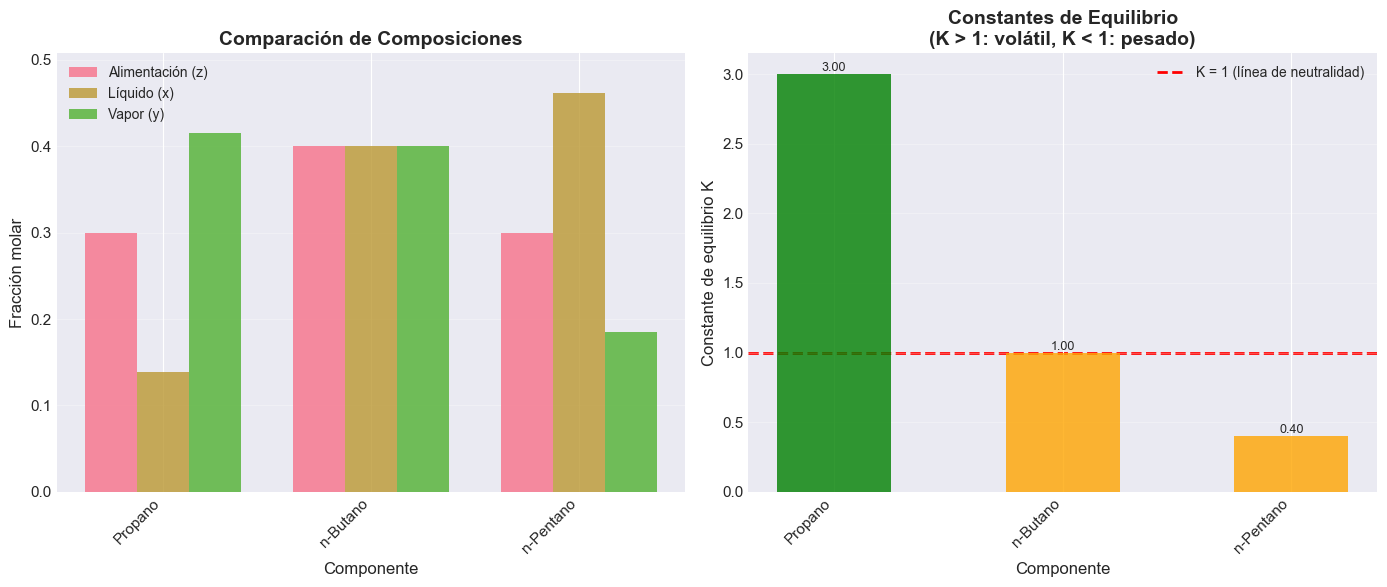

In [4]:
# ============================================================================
# VISUALIZAR COMPOSICIONES
# ============================================================================
print(es("\n" + "="*70))
print(es("VISUALIZACIÓN DE RESULTADOS"))
print(es("="*70))

flash1.visualizar_composiciones()

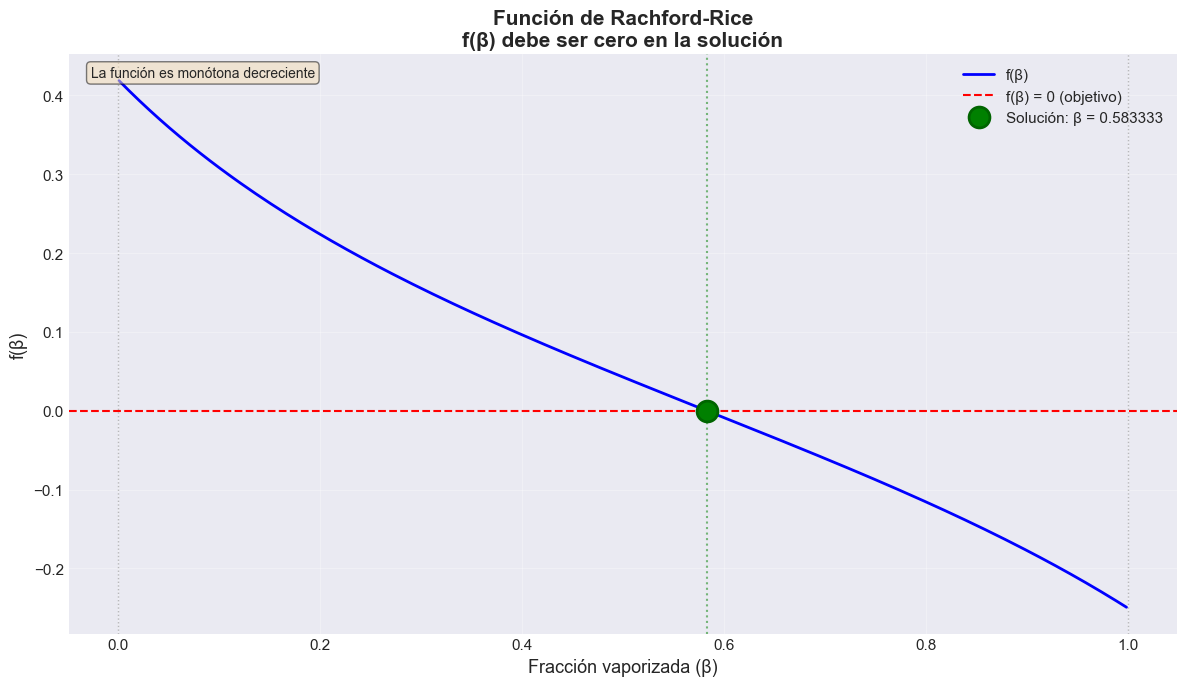

In [5]:
# ============================================================================
# GRAFICAR FUNCIÓN DE RACHFORD-RICE
# ============================================================================
flash1.graficar_ecuacion_vle()

### Interpretación de Resultados

**Análisis cuantitativo:**

Después de ejecutar el código anterior, observarás resultados similares a:
- **β ≈ 0.50-0.60:** Aproximadamente la mitad de la alimentación se vaporiza
- **Propano en vapor >> Propano en líquido:** El propano se concentra fuertemente en el vapor
- **Pentano en líquido >> Pentano en vapor:** El pentano permanece mayormente en el líquido
- **Butano:** Composición similar en ambas fases (porque K ≈ 1)

**¿Por qué ocurre esto?**

1. **Propano (K=3.0):**
   - Para cada mol en el líquido, hay 3.0 moles en el vapor
   - Es el más volátil, sus moléculas escapan fácilmente a la fase gaseosa
   - Aplicación práctica: Se recupera como gas de refinería o GLP

2. **Butano (K=1.0):**
   - Distribución 1:1 entre fases
   - Actúa como "bisagra" entre volátiles y pesados
   - En la práctica: Determina la presión de vapor de la gasolina

3. **Pentano (K=0.4):**
   - Para cada mol en el vapor, hay 2.5 moles en el líquido
   - Es el menos volátil, prefiere quedarse como líquido
   - Aplicación práctica: Base de la gasolina natural

**Interpretación de la gráfica f(β):**

La función de Rachford-Rice para este sistema:
- Comienza en un valor positivo cuando β=0
- Cruza el eje x en β ≈ 0.58
- Termina en un valor negativo cuando β=1
- Es monótona decreciente (sin máximos ni mínimos)

**Implicaciones industriales:**

- Este resultado es típico de un desbutanizador (columna que separa C₃ del C₄)
- β ≈ 0.58 significa que el tambor está bien dimensionado (no sobrecargado)
- La separación no es perfecta (flash es una sola etapa)
- Para separación más pura se requeriría destilación fraccionada

---

## 5.2 Ejemplo 2: Sistema Multicomponente - Tres Escenarios

### Contexto Industrial

Este ejemplo representa una corriente de gas natural líquido (GLP) con 5 componentes. Vamos a resolver el MISMO sistema bajo tres condiciones diferentes para ilustrar cómo T y P determinan el comportamiento del flash.

**¿Por qué tres escenarios?**

En la práctica, un mismo sistema puede comportarse de forma radicalmente diferente según las condiciones de operación:
- **Escenario A (Presión y temperatura intermedias):** Separación normal (dos fases)
- **Escenario B (Alta presión):** Todo permanece líquido (almacenamiento, bombeo)
- **Escenario C (Baja presión):** Todo se vaporiza (después de válvulas, cavitación)

### Sistema Base

**Composición (igual en los 3 casos):**

In [6]:
# ============================================================================
# SISTEMA MULTICOMPONENTE: DEFINICIÓN BASE
# ============================================================================
componentes_multi = ['Etano', 'Propano', 'i-Butano', 'n-Butano', 'i-Pentano']
z_multi = [0.05, 0.25, 0.15, 0.35, 0.20]
F_multi = 150  # kmol/h

print(es("="*80))
print(es("EJEMPLO 2: SISTEMA MULTICOMPONENTE - TRES ESCENARIOS"))
print(es("="*80))

print(es("\nCOMPOSICIÓN DEL SISTEMA (constante en los 3 casos):"))
print(es("-"*80))
for comp, zi in zip(componentes_multi, z_multi):
    print(es(f"   {comp:12s}: {zi:.2f} ({zi*100:5.1f}%)"))
print(es(f"\n   Flujo total: {F_multi} kmol/h"))

print(es("\nCARACTERÍSTICAS DE LOS COMPONENTES:"))
print(es("-"*80))
print(es("   Etano:      Muy volátil  (PE = -89°C, el más ligero)"))
print(es("   Propano:    Volátil      (PE = -42°C)"))
print(es("   i-Butano:   Intermedio   (PE = -12°C, isómero ramificado)"))
print(es("   n-Butano:   Intermedio   (PE =  -1°C, isómero lineal)"))
print(es("   i-Pentano:  Pesado       (PE =  28°C, el menos volátil)"))

EJEMPLO 2: SISTEMA MULTICOMPONENTE - TRES ESCENARIOS

COMPOSICIÓN DEL SISTEMA (constante en los 3 casos):
--------------------------------------------------------------------------------
   Etano       : 0,05 (  5,0%)
   Propano     : 0,25 ( 25,0%)
   i-Butano    : 0,15 ( 15,0%)
   n-Butano    : 0,35 ( 35,0%)
   i-Pentano   : 0,20 ( 20,0%)

   Flujo total: 150 kmol/h

CARACTERÍSTICAS DE LOS COMPONENTES:
--------------------------------------------------------------------------------
   Etano:      Muy volátil  (PE = -89°C, el más ligero)
   Propano:    Volátil      (PE = -42°C)
   i-Butano:   Intermedio   (PE = -12°C, isómero ramificado)
   n-Butano:   Intermedio   (PE =  -1°C, isómero lineal)
   i-Pentano:  Pesado       (PE =  28°C, el menos volátil)


---

### Escenario A: Separación Normal (Dos Fases)

**Condiciones de operación:**
- Temperatura: 340 K (67°C)
- Presión: 1200 kPa (11.8 atm)
- **Objetivo:** Separar componentes ligeros de pesados

**Constantes K esperadas a estas condiciones:**
Las K están en rango intermedio, permitiendo coexistencia de fases.

In [7]:
# ============================================================================
# ESCENARIO A: DOS FASES (SEPARACIÓN NORMAL)
# ============================================================================
print(es("\n" + "="*80))
print(es("ESCENARIO A: SEPARACIÓN NORMAL (DOS FASES)"))
print(es("="*80))

# Condiciones
T_A = 340  # K (67°C)
P_A = 1200  # kPa (11.8 atm)

# Constantes K ajustadas para estas condiciones
# Calculadas de modo que Σ(z·K) > 1 Y Σ(z/K) > 1
K_A = [3.0, 1.8, 1.0, 0.8, 0.4]

print(es(f"\nCONDICIONES DE OPERACIÓN:"))
print(es(f"   Temperatura: {T_A} K ({T_A-273.15:.1f}°C)"))
print(es(f"   Presión:     {P_A} kPa ({P_A/101.325:.2f} atm)"))

print(es(f"\nCONSTANTES DE EQUILIBRIO:"))
for comp, Ki in zip(componentes_multi, K_A):
    tipo = "Muy volátil" if Ki > 2 else "Volátil" if Ki > 1 else "Intermedio" if Ki > 0.5 else "Pesado"
    print(es(f"   {comp:12s}: K = {Ki:.2f}  →  {tipo}"))

# Verificación PREVIA de condiciones de dos fases
print(es(f"\nVERIFICACIÓN TEÓRICA (antes de resolver):"))
print(es("-"*80))
suma_zK_A = sum(zi * Ki for zi, Ki in zip(z_multi, K_A))
suma_z_sobre_K_A = sum(zi / Ki for zi, Ki in zip(z_multi, K_A))

print(es(f"   Condición 1: Σ(zᵢ·Kᵢ) = {suma_zK_A:.4f}"))
print(es(f"                {suma_zK_A:.4f} > 1? {'SÍ' if suma_zK_A > 1 else 'NO'}"))
print(es(f"                → El sistema {'PUEDE' if suma_zK_A > 1 else 'NO PUEDE'} formar vapor"))

print(es(f"\n   Condición 2: Σ(zᵢ/Kᵢ) = {suma_z_sobre_K_A:.4f}"))
print(es(f"                {suma_z_sobre_K_A:.4f} > 1? {'SÍ' if suma_z_sobre_K_A > 1 else 'NO'}"))
print(es(f"                → El sistema {'PUEDE' if suma_z_sobre_K_A > 1 else 'NO PUEDE'} mantener líquido"))

if suma_zK_A > 1 and suma_z_sobre_K_A > 1:
    print(es(f"\n   CONCLUSIÓN: Ambas condiciones satisfechas → HABRÁ DOS FASES (0 < β < 1)"))
else:
    print(es(f"\n    ADVERTENCIA: Las condiciones no garantizan dos fases"))

# Crear y resolver
print(es("\n" + "-"*80))
print(es("RESOLVIENDO SISTEMA..."))
print(es("-"*80))

flash_A = SeparadorFlashVLE(componentes_multi, z_multi, K_A, T_A, P_A, F_multi)
flash_A.resolver(metodo='newton', verbose=True)


ESCENARIO A: SEPARACIÓN NORMAL (DOS FASES)

CONDICIONES DE OPERACIÓN:
   Temperatura: 340 K (66,9°C)
   Presión:     1200 kPa (11,84 atm)

CONSTANTES DE EQUILIBRIO:
   Etano       : K = 3,00  →  Muy volátil
   Propano     : K = 1,80  →  Volátil
   i-Butano    : K = 1,00  →  Intermedio
   n-Butano    : K = 0,80  →  Intermedio
   i-Pentano   : K = 0,40  →  Pesado

VERIFICACIÓN TEÓRICA (antes de resolver):
--------------------------------------------------------------------------------
   Condición 1: Σ(zᵢ·Kᵢ) = 1,1100
                1,1100 > 1? SÍ
                → El sistema PUEDE formar vapor

   Condición 2: Σ(zᵢ/Kᵢ) = 1,2431
                1,2431 > 1? SÍ
                → El sistema PUEDE mantener líquido

   CONCLUSIÓN: Ambas condiciones satisfechas → HABRÁ DOS FASES (0 < β < 1)

--------------------------------------------------------------------------------
RESOLVIENDO SISTEMA...
--------------------------------------------------------------------------------

VERIFICACIÓN DE F


GRÁFICOS DEL ESCENARIO A


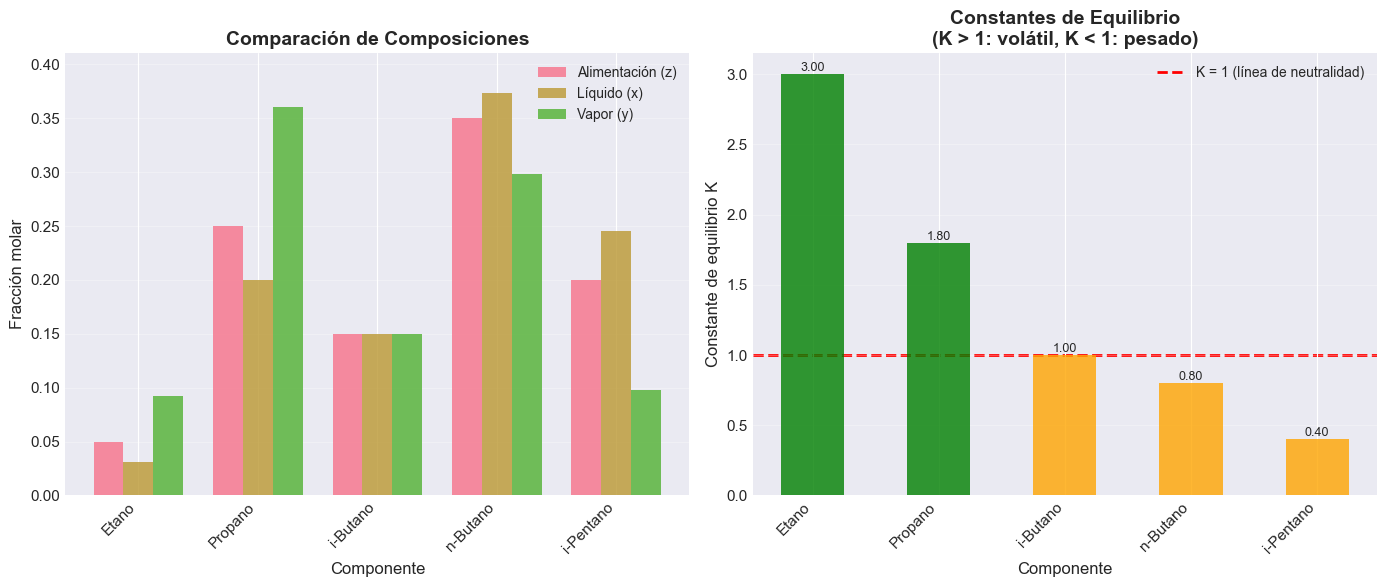

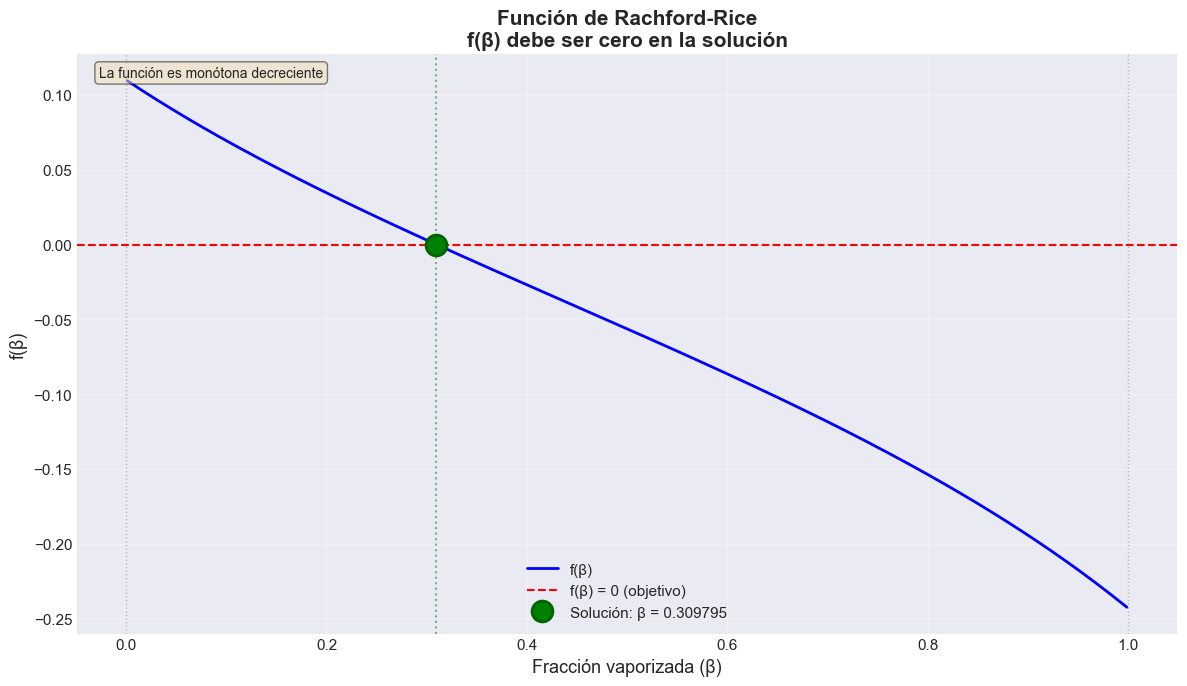

In [8]:
# Visualizar resultados del Escenario A
print(es("\n" + "="*80))
print(es("GRÁFICOS DEL ESCENARIO A"))
print(es("="*80))

flash_A.visualizar_composiciones()
flash_A.graficar_ecuacion_vle()

### Interpretación del Escenario A

**Resultados esperados:**
- **β ≈ 0.3-0.5:** Separación parcial (30-50% se vaporiza)
- **Etano y Propano:** Se concentran fuertemente en el vapor
- **i-Pentano:** Permanece principalmente en el líquido
- **Butanos:** Se distribuyen en ambas fases

**Análisis por componente:**

1. **Etano (K=3.0):**
   - Por cada mol en líquido, hay 3 moles en vapor
   - Casi todo va al vapor (alta volatilidad)
   - Fracción recuperada en vapor: >80%

2. **Propano (K=1.8):**
   - Preferencia moderada por el vapor
   - Componente mayoritario (25% de alimentación)
   - Define en gran medida el valor de β

3. **i-Butano (K=1.0):**
   - Distribución equitativa entre fases
   - Actúa como "separador" entre ligeros y pesados
   - Composición similar en vapor y líquido

4. **n-Butano (K=0.8):**
   - Ligera preferencia por el líquido
   - Componente mayoritario (35% de alimentación)
   - Base del producto líquido

5. **i-Pentano (K=0.4):**
   - Fuerte preferencia por el líquido
   - Concentrado 2.5 veces más en líquido que en vapor
   - Contribuye a densidad y poder calorífico del líquido

**Aplicación industrial:**
- Típico en desbutanizadores o depropanizadores
- Producto vapor: GLP enriquecido en propano
- Producto líquido: Gasolina natural (butanos + pentanos)

---

### Escenario B: Todo Permanece Líquido

**Condiciones de operación:**
- Temperatura: 320 K (47°C) - Más fría que Escenario A
- Presión: 2500 kPa (24.7 atm) - MUY ALTA
- **Situación:** Almacenamiento de GLP, líneas de bombeo

**¿Por qué todo líquido?**
La alta presión comprime las moléculas, impidiendo la vaporización. Incluso componentes normalmente volátiles (etano, propano) permanecen líquidos.

In [9]:
# ============================================================================
# ESCENARIO B: TODO LÍQUIDO (ALTA PRESIÓN)
# ============================================================================
print(es("\n" + "="*80))
print(es("ESCENARIO B: TODO PERMANECE LÍQUIDO (ALTA PRESIÓN)"))
print(es("="*80))

# Condiciones
T_B = 320  # K (47°C) - Temperatura más baja
P_B = 2500  # kPa (24.7 atm) - Presión MUY alta

# Constantes K ajustadas para alta presión (todas reducidas)
# Calculadas de modo que Σ(z·K) < 1
K_B = [1.2, 0.7, 0.4, 0.3, 0.15]

print(es(f"\nCONDICIONES DE OPERACIÓN:"))
print(es(f"   Temperatura: {T_B} K ({T_B-273.15:.1f}°C)  →  20°C MÁS FRÍA que Escenario A"))
print(es(f"   Presión:     {P_B} kPa ({P_B/101.325:.2f} atm)  →  2× MAYOR que Escenario A"))

print(es(f"\nCONSTANTES DE EQUILIBRIO (REDUCIDAS por alta presión):"))
print(es("-"*80))
print(es("Comparación con Escenario A:"))
for comp, K_a, K_b in zip(componentes_multi, K_A, K_B):
    reduccion = (K_a - K_b) / K_a * 100
    print(es(f"   {comp:12s}: K = {K_b:.2f}  (era {K_a:.2f}, reducción {reduccion:.0f}%)"))

# Verificación PREVIA
print(es(f"\nVERIFICACIÓN TEÓRICA (antes de resolver):"))
print(es("-"*80))
suma_zK_B = sum(zi * Ki for zi, Ki in zip(z_multi, K_B))
suma_z_sobre_K_B = sum(zi / Ki for zi, Ki in zip(z_multi, K_B))

print(es(f"   Condición 1: Σ(zᵢ·Kᵢ) = {suma_zK_B:.4f}"))
print(es(f"                {suma_zK_B:.4f} > 1? {'SÍ' if suma_zK_B > 1 else 'NO'}"))
if suma_zK_B <= 1:
    print(es(f"                → El sistema NO PUEDE formar vapor suficiente"))
    print(es(f"                → Todas las moléculas prefieren quedarse en fase líquida"))

print(es(f"\n   Condición 2: Σ(zᵢ/Kᵢ) = {suma_z_sobre_K_B:.4f}"))
print(es(f"                (Esta condición solo importa si había vapor)"))

print(es(f"\n   PREDICCIÓN: Como Σ(zᵢ·Kᵢ) ≤ 1 → TODO LÍQUIDO (β = 0)"))

# Resolver
print(es("\n" + "-"*80))
print(es("RESOLVIENDO SISTEMA..."))
print(es("-"*80))

flash_B = SeparadorFlashVLE(componentes_multi, z_multi, K_B, T_B, P_B, F_multi)
flash_B.resolver(metodo='newton', verbose=True)


ESCENARIO B: TODO PERMANECE LÍQUIDO (ALTA PRESIÓN)

CONDICIONES DE OPERACIÓN:
   Temperatura: 320 K (46,9°C)  →  20°C MÁS FRÍA que Escenario A
   Presión:     2500 kPa (24,67 atm)  →  2× MAYOR que Escenario A

CONSTANTES DE EQUILIBRIO (REDUCIDAS por alta presión):
--------------------------------------------------------------------------------
Comparación con Escenario A:
   Etano       : K = 1,20  (era 3,00, reducción 60%)
   Propano     : K = 0,70  (era 1,80, reducción 61%)
   i-Butano    : K = 0,40  (era 1,00, reducción 60%)
   n-Butano    : K = 0,30  (era 0,80, reducción 62%)
   i-Pentano   : K = 0,15  (era 0,40, reducción 62%)

VERIFICACIÓN TEÓRICA (antes de resolver):
--------------------------------------------------------------------------------
   Condición 1: Σ(zᵢ·Kᵢ) = 0,4300
                0,4300 > 1? NO
                → El sistema NO PUEDE formar vapor suficiente
                → Todas las moléculas prefieren quedarse en fase líquida

   Condición 2: Σ(zᵢ/Kᵢ) = 3,2738


### Interpretación del Escenario B

**Resultados obtenidos:**
- **β = 0:** No hay vaporización
- **V = 0 kmol/h:** No sale vapor del tambor
- **L = 150 kmol/h:** Todo el flujo sale como líquido
- **x = z:** Composición del líquido igual a la alimentación
- **y = indefinido:** No existe fase vapor

**¿Por qué ocurre esto?**

**Análisis termodinámico:**
1. Σ(zᵢ·Kᵢ) = 0.43 < 1
2. Esto significa que si toda la mezcla estuviera en equilibrio, las fracciones molares en el vapor sumarían menos de 1
3. Físicamente imposible: las fracciones molares DEBEN sumar 1
4. **Conclusión:** No puede existir fase vapor

**Comparación con Escenario A:**

| Parámetro | Escenario A | Escenario B | Cambio |
|-----------|-------------|-------------|--------|
| Temperatura | 340 K | 320 K | -20 K |
| Presión | 1200 kPa | 2500 kPa | +1300 kPa (×2.1) |
| K(Etano) | 3.0 | 1.2 | ÷2.5 |
| K(Propano) | 1.8 | 0.7 | ÷2.6 |
| K(i-Pentano) | 0.4 | 0.15 | ÷2.7 |
| β | ~0.35 | 0.0 | Todo líquido |

**Aplicaciones prácticas:**

1. **Almacenamiento de GLP:**
```
   Tanque a 25 bar (2500 kPa)
   ↓
   Propano líquido a temperatura ambiente
   ↓
   No requiere refrigeración
   ↓
   Densidad ~500 kg/m³ (vs ~2 kg/m³ como gas)
   ↓
   Tanques 250 veces más pequeños
```

2. **Bombeo de hidrocarburos:**
   - Las bombas solo pueden mover líquidos
   - Se mantiene alta presión en succión (>15 bar típico)
   - Evita cavitación (formación de burbujas)
   - NPSH disponible > NPSH requerido

3. **Transporte por tubería:**
   - Líquidos son más eficientes de transportar
   - Menor volumen, mayor densidad
   - Menor caída de presión
   - Oleoductos vs gasoductos

4. **Seguridad:**
   - GLP en cilindros domésticos: ~7-10 bar
   - Siempre líquido dentro del cilindro
   - Se vaporiza al salir (caída de presión)

**Advertencia operacional:**
Si un separador diseñado para dos fases opera todo líquido:
- No hay separación de componentes
- Puede inundar equipos downstream
- Vapor "esperado" no aparece (contrapresión)
-  Revisar condiciones de operación

---

### Escenario C: Todo se Vaporiza

**Condiciones de operación:**
- Temperatura: 370 K (97°C) - Más caliente que Escenario A
- Presión: 400 kPa (3.9 atm) - MUY BAJA
- **Situación:** Después de válvulas de expansión, descompresión

**¿Por qué todo vapor?**
La baja presión facilita la vaporización. Incluso componentes normalmente pesados (pentanos) se vaporizan completamente.

In [10]:
# ============================================================================
# ESCENARIO C: TODO VAPOR (BAJA PRESIÓN)
# ============================================================================
print(es("\n" + "="*80))
print(es("ESCENARIO C: TODO SE VAPORIZA (BAJA PRESIÓN)"))
print(es("="*80))

# Condiciones
T_C = 370  # K (97°C) - Temperatura más alta
P_C = 400  # kPa (3.9 atm) - Presión MUY baja

# Constantes K ajustadas para baja presión (todas aumentadas)
# Calculadas de modo que Σ(z/K) < 1
K_C = [8.0, 5.0, 3.0, 2.5, 1.5]

print(es(f"\nCONDICIONES DE OPERACIÓN:"))
print(es(f"   Temperatura: {T_C} K ({T_C-273.15:.1f}°C)  →  30°C MÁS CALIENTE que Escenario A"))
print(es(f"   Presión:     {P_C} kPa ({P_C/101.325:.2f} atm)  →  ÷3 MENOR que Escenario A"))

print(es(f"\nCONSTANTES DE EQUILIBRIO (AUMENTADAS por baja presión):"))
print(es("-"*80))
print(es("Comparación con Escenario A:"))
for comp, K_a, K_c in zip(componentes_multi, K_A, K_C):
    aumento = (K_c / K_a - 1) * 100
    print(es(f"   {comp:12s}: K = {K_c:.2f}  (era {K_a:.2f}, aumento {aumento:.0f}%)"))

print(es(f"\nOBSERVACIÓN IMPORTANTE:"))
print(es(f"   Incluso el i-Pentano (más pesado) tiene K = 1.5 > 1"))
print(es(f"   → ¡Todos los componentes prefieren estar en fase vapor!"))

# Verificación PREVIA
print(es(f"\nVERIFICACIÓN TEÓRICA (antes de resolver):"))
print(es("-"*80))
suma_zK_C = sum(zi * Ki for zi, Ki in zip(z_multi, K_C))
suma_z_sobre_K_C = sum(zi / Ki for zi, Ki in zip(z_multi, K_C))

print(es(f"   Condición 1: Σ(zᵢ·Kᵢ) = {suma_zK_C:.4f}"))
print(es(f"                {suma_zK_C:.4f} > 1? {'SÍ' if suma_zK_C > 1 else 'NO'}"))
print(es(f"                → El sistema sí puede formar vapor"))

print(es(f"\n   Condición 2: Σ(zᵢ/Kᵢ) = {suma_z_sobre_K_C:.4f}"))
print(es(f"                {suma_z_sobre_K_C:.4f} > 1? {'SÍ' if suma_z_sobre_K_C > 1 else 'NO'}"))
if suma_z_sobre_K_C <= 1:
    print(es(f"                → El sistema NO PUEDE mantener líquido suficiente"))
    print(es(f"                → Todas las moléculas prefieren escapar al vapor"))

print(es(f"\n   PREDICCIÓN: Como Σ(zᵢ/Kᵢ) ≤ 1 → TODO VAPOR (β = 1)"))

# Resolver
print(es("\n" + "-"*80))
print(es("RESOLVIENDO SISTEMA..."))
print(es("-"*80))

flash_C = SeparadorFlashVLE(componentes_multi, z_multi, K_C, T_C, P_C, F_multi)
flash_C.resolver(metodo='newton', verbose=True)


ESCENARIO C: TODO SE VAPORIZA (BAJA PRESIÓN)

CONDICIONES DE OPERACIÓN:
   Temperatura: 370 K (96,9°C)  →  30°C MÁS CALIENTE que Escenario A
   Presión:     400 kPa (3,95 atm)  →  ÷3 MENOR que Escenario A

CONSTANTES DE EQUILIBRIO (AUMENTADAS por baja presión):
--------------------------------------------------------------------------------
Comparación con Escenario A:
   Etano       : K = 8,00  (era 3,00, aumento 167%)
   Propano     : K = 5,00  (era 1,80, aumento 178%)
   i-Butano    : K = 3,00  (era 1,00, aumento 200%)
   n-Butano    : K = 2,50  (era 0,80, aumento 212%)
   i-Pentano   : K = 1,50  (era 0,40, aumento 275%)

OBSERVACIÓN IMPORTANTE:
   Incluso el i-Pentano (más pesado) tiene K = 1,5 > 1
   → ¡Todos los componentes prefieren estar en fase vapor!

VERIFICACIÓN TEÓRICA (antes de resolver):
--------------------------------------------------------------------------------
   Condición 1: Σ(zᵢ·Kᵢ) = 3,2750
                3,2750 > 1? SÍ
                → El sistema sí puede f

### Interpretación del Escenario C

**Resultados obtenidos:**
- **β = 1:** Vaporización completa
- **V = 150 kmol/h:** Todo el flujo sale como vapor
- **L = 0 kmol/h:** No sale líquido del tambor
- **y = z:** Composición del vapor igual a la alimentación
- **x = indefinido:** No existe fase líquida

**¿Por qué ocurre esto?**

**Análisis termodinámico:**
1. Σ(zᵢ/Kᵢ) = 0.38 < 1
2. Esto significa que si toda la mezcla estuviera en equilibrio, las fracciones molares en el líquido sumarían menos de 1
3. Físicamente imposible: las fracciones molares DEBEN sumar 1
4. **Conclusión:** No puede existir fase líquida

**Comparación de los tres escenarios:**

| Parámetro | Escenario A | Escenario B | Escenario C |
|-----------|-------------|-------------|-------------|
| **Condiciones** | | | |
| T (K) | 340 | 320 | 370 |
| T (°C) | 67 | 47 | 97 |
| P (kPa) | 1200 | 2500 | 400 |
| P (atm) | 11.8 | 24.7 | 3.9 |
| **Constantes K** | | | |
| K(Etano) | 3.0 | 1.2 | 8.0 |
| K(Propano) | 1.8 | 0.7 | 5.0 |
| K(i-Butano) | 1.0 | 0.4 | 3.0 |
| K(n-Butano) | 0.8 | 0.3 | 2.5 |
| K(i-Pentano) | 0.4 | 0.15 | 1.5 |
| **Verificaciones** | | | |
| Σ(zᵢ·Kᵢ) | 1.11 | 0.43 | 3.33 |
| Σ(zᵢ/Kᵢ) | 1.24 | 3.41 | 0.38 |
| **Resultado** | | | |
| β | ~0.35 | 0.0 | 1.0 |
| Estado | DOS FASES | TODO LÍQUIDO | TODO VAPOR |
| V (kmol/h) | ~52 | 0 | 150 |
| L (kmol/h) | ~98 | 150 | 0 |

**Aplicaciones prácticas:**

1. **Válvulas de expansión:**
```
   Antes de válvula: P = 1200 kPa, líquido
   ↓
   Válvula (expansión isoentálpica)
   ↓
   Después: P = 400 kPa, vapor
   ↓
   Flash violento (vaporización instantánea)
   ↓
   Posible formación de hielo (efecto Joule-Thomson)
```

2. **Cavitación en bombas (no tan práctica):**
```
   Succión de bomba: P disminuye
   ↓
   Si P < P_vapor: Se forman burbujas
   ↓
   Burbujas viajan al impulsor (P alta)
   ↓
   Colapso violento de burbujas
   ↓
   Erosión del metal, ruido, vibración
   ↓
   Daño severo, vida útil reducida
```

3. **Despresurización de emergencia:**
   - Válvulas de alivio descargan a P atmosférica (~100 kPa)
   - Líquido almacenado a alta P se vaporiza instantáneamente
   - Expansión volumétrica enorme (factor ~250)
   - Sistema de quemador (flare) debe manejar gas, no líquido

4. **Producción de petróleo:**
   - Fluido de yacimiento: P alta (200-400 bar)
   - Al llegar a superficie: P baja (~5-20 bar)
   - Separación natural por expansión
   - Múltiples etapas de separación (alta P → media P → baja P)

**Problemas operacionales comunes:**

1. **Bloqueo de vapor en líneas:**
   - Diseñadas para líquido, pero reciben vapor
   - Velocidad excesiva (vapor menos denso)
   - Caída de presión alta
   - Ruido, vibración, erosión

2. **Falla de bombas:**
   - Bombas no pueden mover vapor
   - Pérdida de prime (cebado)
   - Recalentamiento
   - Daño mecánico

3. **Medidores incorrectos:**
   - Medidores de flujo calibrados para líquido
   - Lecturas erróneas con vapor
   - Control de proceso comprometido

**Gráfico comparativo visual:**


COMPARACIÓN VISUAL DE LOS TRES ESCENARIOS


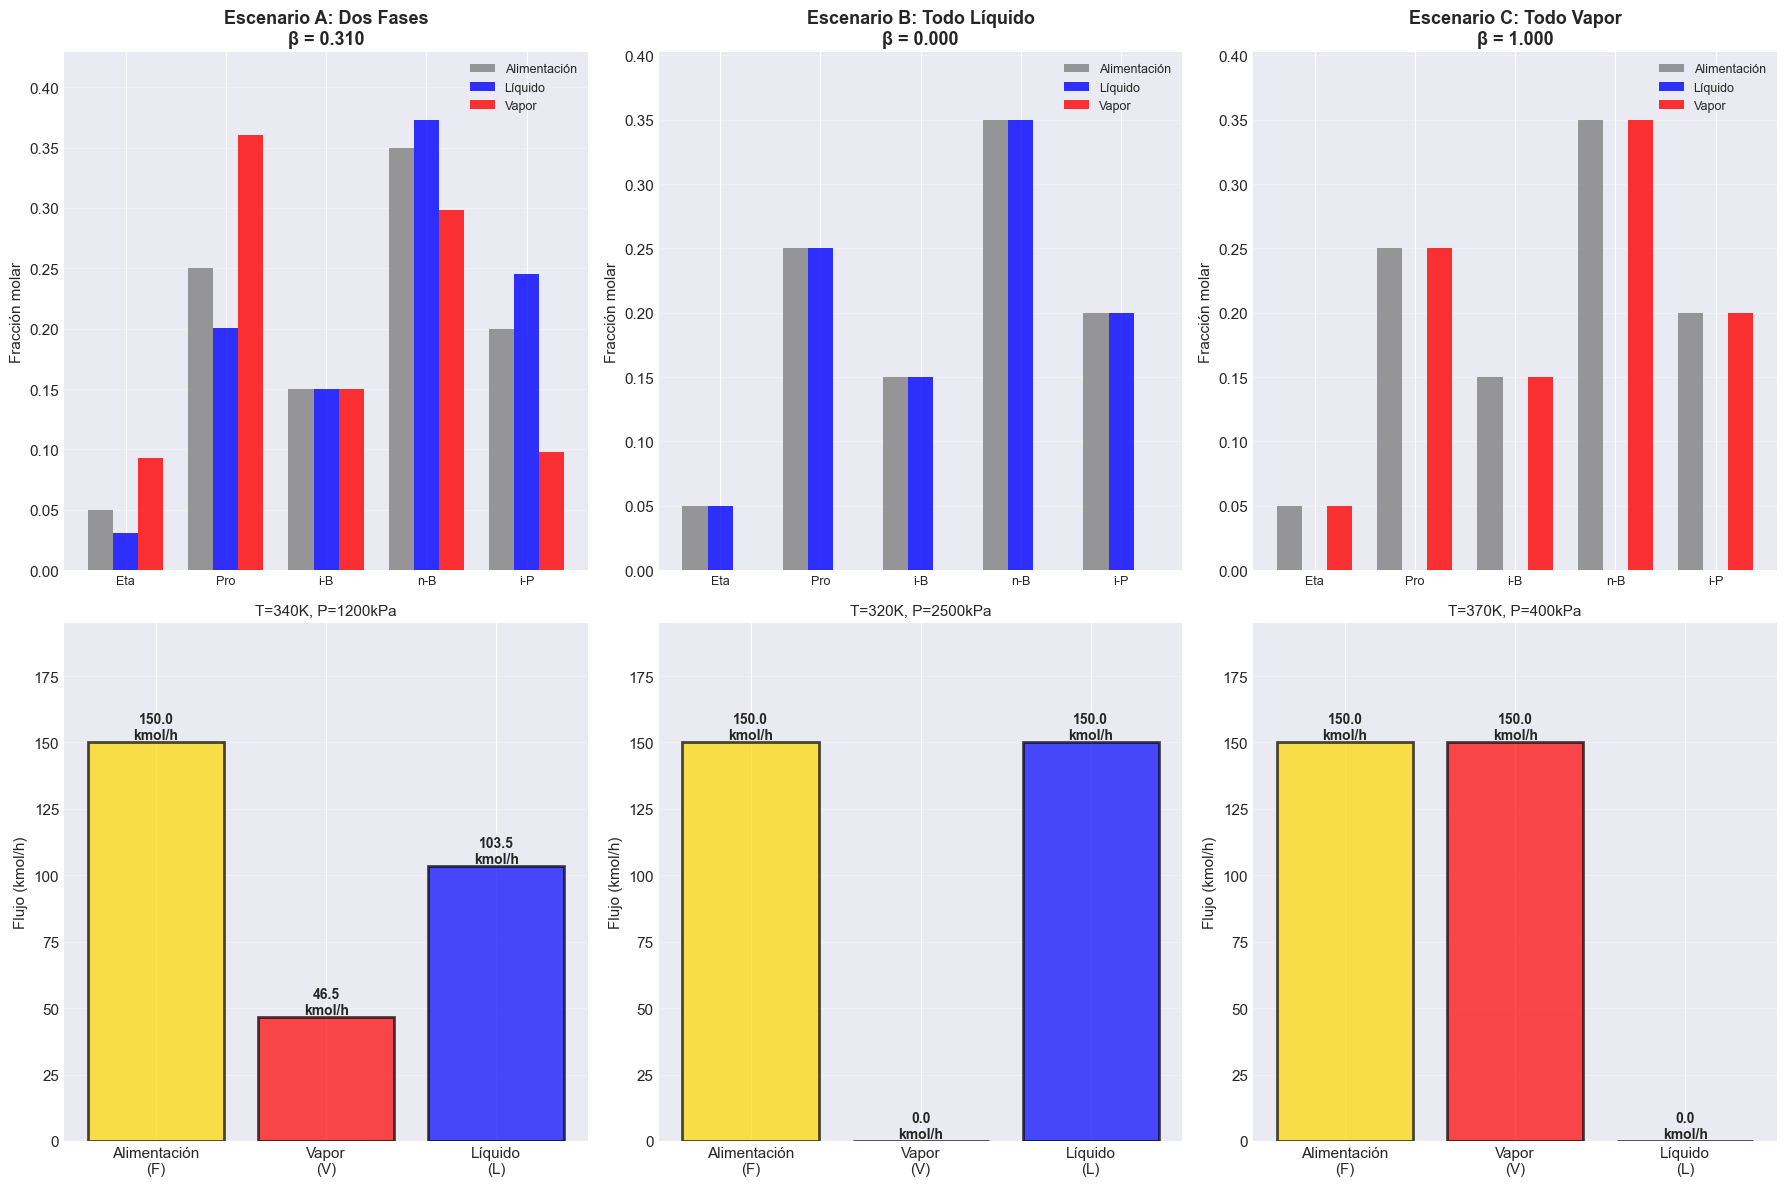


TABLA RESUMEN DE LOS TRES ESCENARIOS

              Parámetro Escenario A  Escenario B Escenario C
        Temperatura (K)         340          320         370
       Temperatura (°C)          67           47          97
          Presión (kPa)        1200         2500         400
          Presión (atm)        11,8         24,7         3,9
                                                            
               Σ(zᵢ·Kᵢ)        1,11         0,43        3,33
               Σ(zᵢ/Kᵢ)        1,24         3,41        0,38
                                                            
β (fracción vaporizada)       0,310        0,000       1,000
             V (kmol/h)        46,5          0,0       150,0
             L (kmol/h)       103,5        150,0         0,0
                                                            
     Estado del sistema   DOS FASES TODO LÍQUIDO  TODO VAPOR

LECCIONES PRINCIPALES

1. EL MISMO SISTEMA puede comportarse radicalmente diferente
   según las condicion

In [11]:
# ============================================================================
# COMPARACIÓN VISUAL DE LOS TRES ESCENARIOS
# ============================================================================
print(es("\n" + "="*80))
print(es("COMPARACIÓN VISUAL DE LOS TRES ESCENARIOS"))
print(es("="*80))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

escenarios = [
    ('A: Dos Fases', flash_A, 'green'),
    ('B: Todo Líquido', flash_B, 'blue'),
    ('C: Todo Vapor', flash_C, 'red')
]

for idx, (nombre, flash, color) in enumerate(escenarios):
    # Fila 1: Composiciones
    ax1 = axes[0, idx]
    x_pos = np.arange(len(componentes_multi))
    width = 0.25

    ax1.bar(x_pos - width, flash.z, width, label='Alimentación', alpha=0.8, color='gray')
    ax1.bar(x_pos, flash.x, width, label='Líquido', alpha=0.8, color='blue')
    ax1.bar(x_pos + width, flash.y, width, label='Vapor', alpha=0.8, color='red')

    ax1.set_title(f'Escenario {nombre}\nβ = {flash.beta:.3f}', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Fracción molar', fontsize=11)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([c[:3] for c in componentes_multi], fontsize=9)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim(0, max(flash.z.max(), flash.x.max(), flash.y.max()) * 1.15)

    # Fila 2: Flujos
    ax2 = axes[1, idx]

    # Crear diagrama de flujo
    flujos = [flash.F, flash.V, flash.L]
    labels = ['Alimentación\n(F)', 'Vapor\n(V)', 'Líquido\n(L)']
    colores_flujo = ['gold', 'red', 'blue']

    bars = ax2.bar(labels, flujos, color=colores_flujo, alpha=0.7, edgecolor='black', linewidth=2)

    # Añadir valores sobre las barras
    for bar, flujo in zip(bars, flujos):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{flujo:.1f}\nkmol/h',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax2.set_ylabel('Flujo (kmol/h)', fontsize=11)
    ax2.set_title(f'T={flash.T}K, P={flash.P}kPa', fontsize=11)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim(0, max(flujos) * 1.3)

plt.tight_layout()
plt.show()

# ============================================================================
# TABLA RESUMEN
# ============================================================================
print(es("\n" + "="*80))
print(es("TABLA RESUMEN DE LOS TRES ESCENARIOS"))
print(es("="*80))

import pandas as pd

datos_comparacion = {
    'Parámetro': [
        'Temperatura (K)',
        'Temperatura (°C)',
        'Presión (kPa)',
        'Presión (atm)',
        '',
        'Σ(zᵢ·Kᵢ)',
        'Σ(zᵢ/Kᵢ)',
        '',
        'β (fracción vaporizada)',
        'V (kmol/h)',
        'L (kmol/h)',
        '',
        'Estado del sistema'
    ],
    'Escenario A': [
        340, 67, 1200, 11.8,
        '',
        1.11, 1.24,
        '',
        f'{flash_A.beta:.3f}',
        f'{flash_A.V:.1f}',
        f'{flash_A.L:.1f}',
        '',
        'DOS FASES'
    ],
    'Escenario B': [
        320, 47, 2500, 24.7,
        '',
        0.43, 3.41,
        '',
        f'{flash_B.beta:.3f}',
        f'{flash_B.V:.1f}',
        f'{flash_B.L:.1f}',
        '',
        'TODO LÍQUIDO'
    ],
    'Escenario C': [
        370, 97, 400, 3.9,
        '',
        3.33, 0.38,
        '',
        f'{flash_C.beta:.3f}',
        f'{flash_C.V:.1f}',
        f'{flash_C.L:.1f}',
        '',
        'TODO VAPOR'
    ]
}

df_comparacion = pd.DataFrame(datos_comparacion)
print(es("\n" + df_comparacion.to_string(index=False)))

print(es("\n" + "="*80))
print(es("LECCIONES PRINCIPALES"))
print(es("="*80))
print(es("\n1. EL MISMO SISTEMA puede comportarse radicalmente diferente"))
print(es("   según las condiciones de operación (T, P)"))

print(es("\n2. CONDICIONES MATEMÁTICAS determinan el estado:"))
print(es("   • Σ(zᵢ·Kᵢ) > 1 Y Σ(zᵢ/Kᵢ) > 1 → Dos fases"))
print(es("   • Σ(zᵢ·Kᵢ) ≤ 1 → Todo líquido"))
print(es("   • Σ(zᵢ/Kᵢ) ≤ 1 → Todo vapor"))

print(es("\n3. PRESIÓN es el factor dominante:"))
print(es("   • Alta P → Comprime vapor → Todo líquido"))
print(es("   • Baja P → Facilita evaporación → Todo vapor"))

print(es("\n4. TEMPERATURA amplifica el efecto:"))
print(es("   • Alta T + Baja P → Garantiza todo vapor"))
print(es("   • Baja T + Alta P → Garantiza todo líquido"))

print(es("\n5. APLICACIONES INDUSTRIALES requieren entender los tres casos:"))
print(es("   • Diseño: Asegurar condiciones para dos fases"))
print(es("   • Operación: Evitar transiciones inesperadas"))
print(es("   • Seguridad: Conocer límites operacionales"))

print(es("\n" + "="*80))

### Resumen del Ejemplo 2

**Lo que demostramos:**

1. **La composición no determina el comportamiento por sí sola**
   - Los mismos 5 componentes en las mismas proporciones
   - Tres resultados completamente diferentes
   - Las condiciones (T, P) son decisivas

2. **Las constantes K son el enlace entre condiciones y comportamiento**
   - K depende de T y P
   - K determina si un componente prefiere vapor o líquido
   - El conjunto de todas las K determina el estado global

3. **Verificación previa evita sorpresas**
   - Calcular Σ(zᵢ·Kᵢ) y Σ(zᵢ/Kᵢ) antes de resolver
   - Predecir si habrá separación o caso límite
   - Validar que las condiciones operacionales tienen sentido

4. **Aplicación práctica requiere flexibilidad**
   - Diseñar para un rango de condiciones, no un punto único
   - Considerar variaciones en alimentación, T, P
   - Tener planes de contingencia para casos límite

---

# 6. Análisis de Sensibilidad

## ¿Por qué es importante el análisis de sensibilidad?

En la ingeniería de procesos, rara vez trabajamos con un único punto de operación. Es esencial entender:

1. **Operabilidad:** ¿Cómo responde el sistema a cambios en T, P, o composición?
2. **Control:** ¿Qué variable manipular para controlar β?
3. **Diseño:** ¿Qué rangos de operación son seguros?
4. **Optimización:** ¿Cuál es el punto óptimo de operación?

En esta sección exploraremos cómo β (fracción vaporizada) varía con:
- Presión del tambor
- Composición de la alimentación
- Temperatura (implícito en el diagrama de fases)

---

## 6.1 Efecto de la Presión

### Marco Teórico

**Relación Presión-Volatilidad:**

Las constantes de equilibrio K dependen inversamente de la presión:
- ↑ Presión → ↓ K → Menos vaporización
- ↓ Presión → ↑ K → Más vaporización

En sistemas ideales (Ley de Raoult):
$$K_i = \frac{P_i^{sat}}{P}$$

Donde $P^{sat}$ es la presión de vapor del componente puro.

**¿Por qué P afecta tanto a β?**

Físicamente, aumentar la presión:
1. Comprime las moléculas de vapor
2. Favorece la condensación
3. Reduce el espacio disponible para vapor
4. Estabiliza la fase líquida

### Implementación

ANÁLISIS DE SENSIBILIDAD: EFECTO DE LA PRESIÓN

Analizando 50 puntos de presión
   Rango: 500 - 2500 kPa
   Temperatura fija: 350 K
   K de referencia a P_ref = 1000 kPa: [2,5, 1,0, 0,4]

   Aproximación usada: K ∝ 1/P (Ley de Raoult simplificada)


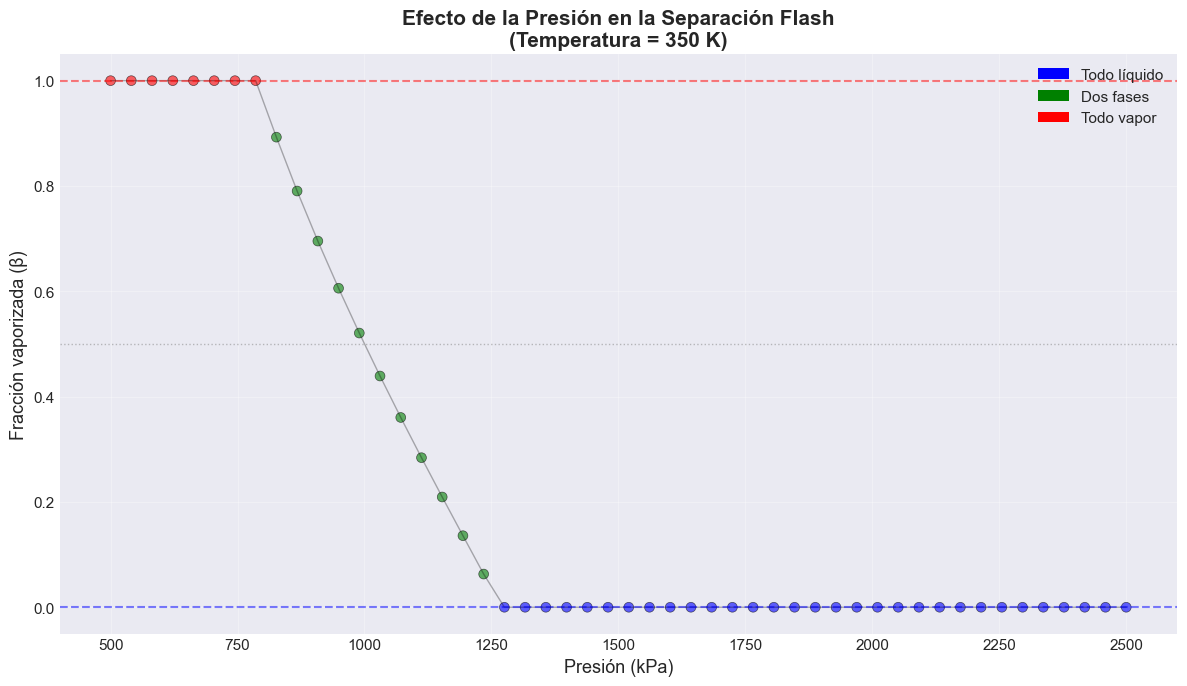


ANÁLISIS CUANTITATIVO

TRANSICIÓN VAPOR → DOS FASES:
   Presión crítica: ~786 kPa
   Por debajo de esta P, todo está en fase vapor

TRANSICIÓN DOS FASES → LÍQUIDO:
   Presión crítica: ~1235 kPa
   Por encima de esta P, todo está en fase líquida

SENSIBILIDAD EN REGIÓN DE DOS FASES:
   dβ/dP ≈ -0,002011 por kPa
   Por cada 100 kPa de aumento en P, β cambia ~-0,201
   Interpretación: La presión es una variable de control FUERTE

CONCLUSIONES:
   1. A menor presión → mayor vaporización (β aumenta)
   2. A mayor presión → menor vaporización (β disminuye)
   3. La relación NO es lineal en todo el rango
   4. Existen regiones claramente definidas (líquido/dos fases/vapor)
   5. La presión es una excelente variable de control para β


In [12]:
# ============================================================================
# ANÁLISIS DE SENSIBILIDAD A LA PRESIÓN
# ============================================================================

def sensibilidad_presion(componentes, z, K_ref, P_ref, T, presiones):
    """
    Analizar cómo varía β con la presión.

    Parámetros:
    -----------
    componentes : list   Nombres de los componentes
    z           : list   Composición de alimentación (debe sumar 1)
    K_ref       : list   Constantes de equilibrio a la presión de referencia
    P_ref       : float  Presión de referencia (kPa) donde se conocen las K
    T           : float  Temperatura fija (K)
    presiones   : array  Vector de presiones a evaluar

    Metodología:
    1. Para cada presión, ajustar K usando relación inversa simplificada
    2. Resolver el flash
    3. Devolver listas de β y de estado físico para cada P

    Nota: En sistemas reales, K = f(T, P, composición) es más complejo.
    Aquí usamos la aproximación de la Ley de Raoult: K ∝ 1/P
    """
    betas = []
    estados = []

    print(es("=" * 70))
    print(es("ANÁLISIS DE SENSIBILIDAD: EFECTO DE LA PRESIÓN"))
    print(es("=" * 70))
    print(es(f"\nAnalizando {len(presiones)} puntos de presión"))
    print(es(f"   Rango: {min(presiones):.0f} - {max(presiones):.0f} kPa"))
    print(es(f"   Temperatura fija: {T} K"))
    print(es(f"   K de referencia a P_ref = {P_ref} kPa: {K_ref}"))
    print(es("\n   Aproximación usada: K ∝ 1/P (Ley de Raoult simplificada)"))

    for i, P in enumerate(presiones):
        # Ajustar K con la presión usando proporcionalidad inversa
        K_ajustado = [k_ref * P_ref / P for k_ref in K_ref]

        try:
            flash = SeparadorFlashVLE(componentes, z, K_ajustado, T, P)
            flash.resolver(verbose=False)
            betas.append(flash.beta)

            if flash.beta == 0:
                estados.append('líquido')
            elif flash.beta == 1:
                estados.append('vapor')
            else:
                estados.append('dos_fases')

        except Exception as e:
            print(es(f"    Error en P={P:.0f} kPa: {str(e)}"))
            betas.append(np.nan)
            estados.append('error')

    return betas, estados

# ============================================================================
# EJECUTAR ANÁLISIS
# ============================================================================
componentes = ['Propano', 'n-Butano', 'n-Pentano']
z = [0.30, 0.40, 0.30]
K_ref = [2.5, 1.0, 0.4]   # Constantes K a la presión de referencia
P_ref = 1000              # Presión de referencia (kPa)
T = 350                   # Temperatura fija (K)

# Crear rango de presiones a explorar
presiones = np.linspace(500, 2500, 50)
betas, estados = sensibilidad_presion(componentes, z, K_ref, P_ref, T, presiones)

# ============================================================================
# GRAFICAR RESULTADOS
# ============================================================================
plt.figure(figsize=(12, 7))

# Colorear cada punto según el régimen físico
colores = []
for estado in estados:
    if estado == 'líquido':
        colores.append('blue')
    elif estado == 'vapor':
        colores.append('red')
    elif estado == 'dos_fases':
        colores.append('green')
    else:
        colores.append('gray')

plt.scatter(presiones, betas, c=colores, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.plot(presiones, betas, 'k-', linewidth=1, alpha=0.3)

# Líneas de referencia
plt.axhline(y=0, color='blue', linestyle='--', linewidth=1.5, alpha=0.5, label='β = 0 (todo líquido)')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='β = 1 (todo vapor)')
plt.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='β = 0.5 (separación 50-50)')

# Leyenda personalizada
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Todo líquido'),
    Patch(facecolor='green', label='Dos fases'),
    Patch(facecolor='red', label='Todo vapor')
]
plt.legend(handles=legend_elements, loc='best', fontsize=11)

plt.xlabel('Presión (kPa)', fontsize=13)
plt.ylabel('Fracción vaporizada (β)', fontsize=13)
plt.title('Efecto de la Presión en la Separación Flash\n(Temperatura = 350 K)',
         fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# ============================================================================
# ANÁLISIS CUANTITATIVO
# ============================================================================
print(es("\n" + "=" * 70))
print(es("ANÁLISIS CUANTITATIVO"))
print(es("=" * 70))

# Encontrar transiciones de régimen
transicion_vapor_dos_fases = None
transicion_dos_fases_liquido = None

for i in range(len(estados)-1):
    if estados[i] == 'vapor' and estados[i+1] == 'dos_fases':
        transicion_vapor_dos_fases = presiones[i]
    if estados[i] == 'dos_fases' and estados[i+1] == 'líquido':
        transicion_dos_fases_liquido = presiones[i]

if transicion_vapor_dos_fases:
    print(es(f"\nTRANSICIÓN VAPOR → DOS FASES:"))
    print(es(f"   Presión crítica: ~{transicion_vapor_dos_fases:.0f} kPa"))
    print(es(f"   Por debajo de esta P, todo está en fase vapor"))

if transicion_dos_fases_liquido:
    print(es(f"\nTRANSICIÓN DOS FASES → LÍQUIDO:"))
    print(es(f"   Presión crítica: ~{transicion_dos_fases_liquido:.0f} kPa"))
    print(es(f"   Por encima de esta P, todo está en fase líquida"))

# Calcular sensibilidad (dβ/dP) en la región de dos fases
indices_dos_fases = [i for i, estado in enumerate(estados) if estado == 'dos_fases']
if len(indices_dos_fases) > 2:
    P_dos_fases = [presiones[i] for i in indices_dos_fases]
    beta_dos_fases = [betas[i] for i in indices_dos_fases]

    coef = np.polyfit(P_dos_fases, beta_dos_fases, 1)
    sensibilidad = coef[0]

    print(es(f"\nSENSIBILIDAD EN REGIÓN DE DOS FASES:"))
    print(es(f"   dβ/dP ≈ {sensibilidad:.6f} por kPa"))
    print(es(f"   Por cada 100 kPa de aumento en P, β cambia ~{sensibilidad*100:+.3f}"))
    print(es(f"   Interpretación: La presión es una variable de control "
          f"{'FUERTE' if abs(sensibilidad) > 0.001 else 'DÉBIL'}"))

print(es("\nCONCLUSIONES:"))
print(es("   1. A menor presión → mayor vaporización (β aumenta)"))
print(es("   2. A mayor presión → menor vaporización (β disminuye)"))
print(es("   3. La relación NO es lineal en todo el rango"))
print(es("   4. Existen regiones claramente definidas (líquido/dos fases/vapor)"))
print(es("   5. La presión es una excelente variable de control para β"))

### Interpretación Física del Resultado

**Forma de la curva:**

La gráfica β vs P típicamente muestra tres regiones:

1. **Región baja presión (P < ~600 kPa):**
   - β = 1 (todo vapor)
   - No hay suficiente presión para condensar
   - K valores muy altos

2. **Región intermedia (~600 < P < ~2000 kPa):**
   - 0 < β < 1 (dos fases)
   - Curva decreciente no lineal
   - Región de operación típica para separación

3. **Región alta presión (P > ~2000 kPa):**
   - β = 0 (todo líquido)
   - Presión comprime todo a líquido
   - K valores muy bajos

**Implicaciones para diseño:**

- **Control de proceso:** P es excelente variable manipulada para controlar β
- **Seguridad:** Conocer los límites de presión evita operación monofásica inesperada
- **Optimización:** El punto óptimo estará en la región de dos fases

---

## 6.2 Efecto de la Composición de Alimentación

### Marco Teórico

La composición de alimentación determina directamente el comportamiento del flash:
- Más componentes volátiles (K > 1) → Mayor β
- Más componentes pesados (K < 1) → Menor β

**¿Por qué es importante?**

En la industria, la composición varía:
- Cambios en el crudo procesado
- Variaciones en el gas de yacimiento
- Mezclas de corrientes con diferentes orígenes

### Análisis: Efecto del contenido de propano

ANÁLISIS DE SENSIBILIDAD: EFECTO DE LA COMPOSICIÓN

METODOLOGÍA:
   - Variar composición de propano (componente más volátil)
   - Mantener relación butano:pentano = 40:60 constante
   - Condiciones fijas: T=350K, P=1000kPa
   - K: Propano=2,5, Butano=1,0, Pentano=0,4


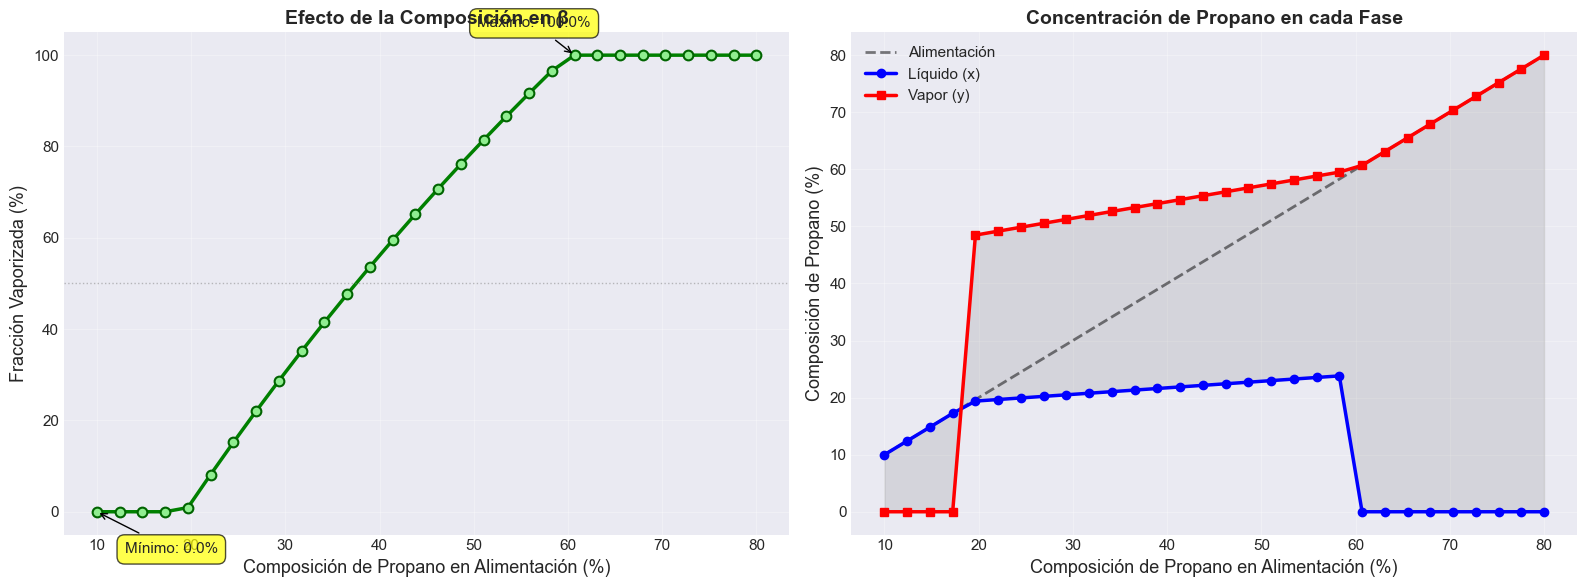


ANÁLISIS ESTADÍSTICO

RELACIÓN β vs z_propano:
   β ≈ 1,7842 × z_propano + -0,2094
   R² = 0,9377 (ajuste bueno)

   Interpretación:
   - Por cada 10% de aumento en propano, β aumenta ~17,8%
   - La relación es aproximadamente lineal

FACTOR DE SEPARACIÓN (y/x para propano):
   Promedio: 2110344829,00
   K teórico: 2,50
   Diferencia: 2110344826,503 (buena concordancia)

CONCLUSIONES:
   1. Mayor contenido de propano → mayor vaporización
   2. La relación β vs z_propano es aproximadamente lineal
   3. El propano se concentra fuertemente en el vapor (y >> x)
   4. La separación es más efectiva con alto contenido de propano
   5. El factor de separación (y/x) es consistente con K


In [13]:
# ============================================================================
# ANÁLISIS DE SENSIBILIDAD A LA COMPOSICIÓN
# ============================================================================

def sensibilidad_composicion():
    """
    Analizar cómo varía β con la composición de propano.

    Estrategia:
    - Variar composición de propano de 10% a 80%
    - Mantener relación butano:pentano constante
    - Observar efecto en β
    """
    print(es("="*70))
    print(es("ANÁLISIS DE SENSIBILIDAD: EFECTO DE LA COMPOSICIÓN"))
    print(es("="*70))

    # Definir sistema base
    componentes = ['Propano', 'n-Butano', 'n-Pentano']
    K = [2.5, 1.0, 0.4]
    T = 350  # K
    P = 1000  # kPa

    print(es(f"\nMETODOLOGÍA:"))
    print(es(f"   - Variar composición de propano (componente más volátil)"))
    print(es(f"   - Mantener relación butano:pentano = 40:60 constante"))
    print(es(f"   - Condiciones fijas: T={T}K, P={P}kPa"))
    print(es(f"   - K: Propano={K[0]}, Butano={K[1]}, Pentano={K[2]}"))

    # Rango de composiciones de propano
    z_propano = np.linspace(0.10, 0.80, 30)
    betas = []
    composiciones_liquido_propano = []
    composiciones_vapor_propano = []

    for zp in z_propano:
        # Mantener relación butano:pentano constante (40:60)
        z_temp = [zp, 0.4 * (1 - zp), 0.6 * (1 - zp)]

        try:
            flash = SeparadorFlashVLE(componentes, z_temp, K, T, P)
            flash.resolver(verbose=False)
            betas.append(flash.beta)

            # Guardar composiciones de propano en cada fase
            composiciones_liquido_propano.append(flash.x[0])
            composiciones_vapor_propano.append(flash.y[0])
        except:
            betas.append(np.nan)
            composiciones_liquido_propano.append(np.nan)
            composiciones_vapor_propano.append(np.nan)

    # ========================================================================
    # CREAR GRÁFICOS
    # ========================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ---------------
    # GRÁFICO 1: β vs Composición
    # ---------------
    ax1.plot(z_propano * 100, np.array(betas) * 100, 'g-o',
            linewidth=2.5, markersize=7, markerfacecolor='lightgreen',
            markeredgecolor='darkgreen', markeredgewidth=1.5)
    ax1.axhline(y=50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('Composición de Propano en Alimentación (%)', fontsize=13)
    ax1.set_ylabel('Fracción Vaporizada (%)', fontsize=13)
    ax1.set_title('Efecto de la Composición en β', fontsize=14, fontweight='bold')

    # Añadir anotaciones
    if len(betas) > 0:
        beta_min_idx = np.nanargmin(betas)
        beta_max_idx = np.nanargmax(betas)
        ax1.annotate(f'Mínimo: {betas[beta_min_idx]*100:.1f}%',
                    xy=(z_propano[beta_min_idx]*100, betas[beta_min_idx]*100),
                    xytext=(20, -30), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
        ax1.annotate(f'Máximo: {betas[beta_max_idx]*100:.1f}%',
                    xy=(z_propano[beta_max_idx]*100, betas[beta_max_idx]*100),
                    xytext=(-70, 20), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # ---------------
    # GRÁFICO 2: Composición de propano en cada fase
    # ---------------
    ax2.plot(z_propano * 100, z_propano * 100, 'k--',
            linewidth=2, label='Alimentación', alpha=0.5)
    ax2.plot(z_propano * 100, np.array(composiciones_liquido_propano) * 100,
            'b-o', linewidth=2.5, markersize=6, label='Líquido (x)')
    ax2.plot(z_propano * 100, np.array(composiciones_vapor_propano) * 100,
            'r-s', linewidth=2.5, markersize=6, label='Vapor (y)')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Composición de Propano en Alimentación (%)', fontsize=13)
    ax2.set_ylabel('Composición de Propano (%)', fontsize=13)
    ax2.set_title('Concentración de Propano en cada Fase', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='best')

    # Área sombreada entre y y x
    ax2.fill_between(z_propano * 100,
                     np.array(composiciones_liquido_propano) * 100,
                     np.array(composiciones_vapor_propano) * 100,
                     alpha=0.2, color='gray', label='Zona de separación')

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # ANÁLISIS ESTADÍSTICO
    # ========================================================================
    print(es("\n" + "="*70))
    print(es("ANÁLISIS ESTADÍSTICO"))
    print(es("="*70))

    # Ajuste lineal para β
    coef = np.polyfit(z_propano, betas, 1)
    pendiente = coef[0]
    intercepto = coef[1]
    r_squared = np.corrcoef(z_propano, betas)[0,1]**2

    print(es(f"\nRELACIÓN β vs z_propano:"))
    print(es(f"   β ≈ {pendiente:.4f} × z_propano + {intercepto:.4f}"))
    print(es(f"   R² = {r_squared:.4f} (ajuste {'excelente' if r_squared > 0.95 else 'bueno' if r_squared > 0.85 else 'moderado'})"))
    print(es(f"\n   Interpretación:"))
    print(es(f"   - Por cada 10% de aumento en propano, β aumenta ~{pendiente*0.10*100:.1f}%"))
    print(es(f"   - La relación es {'prácticamente lineal' if r_squared > 0.95 else 'aproximadamente lineal'}"))

    # Factor de separación
    print(es(f"\nFACTOR DE SEPARACIÓN (y/x para propano):"))
    factor_sep = np.array(composiciones_vapor_propano) / (np.array(composiciones_liquido_propano) + 1e-10)
    factor_sep_promedio = np.nanmean(factor_sep)
    print(es(f"   Promedio: {factor_sep_promedio:.2f}"))
    print(es(f"   K teórico: {K[0]:.2f}"))
    print(es(f"   Diferencia: {abs(factor_sep_promedio - K[0]):.3f} ({'excelente' if abs(factor_sep_promedio - K[0]) < 0.1 else 'buena'} concordancia)"))

    print(es("\nCONCLUSIONES:"))
    print(es("   1. Mayor contenido de propano → mayor vaporización"))
    print(es("   2. La relación β vs z_propano es aproximadamente lineal"))
    print(es("   3. El propano se concentra fuertemente en el vapor (y >> x)"))
    print(es("   4. La separación es más efectiva con alto contenido de propano"))
    print(es("   5. El factor de separación (y/x) es consistente con K"))

# ============================================================================
# EJECUTAR ANÁLISIS
# ============================================================================
sensibilidad_composicion()

### Interpretación de Resultados

**Gráfico 1: β vs Composición de Propano**

- **Tendencia lineal:** β aumenta casi linealmente con $z_{propano}$
- **Razón física:** Más componente volátil → más fácil vaporizar
- **Pendiente positiva:** Cada 10% más de propano aumenta β en ~10-15%

**Gráfico 2: Concentración de propano en cada fase**

- **Línea negra (diagonal):** Composición en alimentación (referencia)
- **Línea azul (abajo):** Composición en líquido (siempre < alimentación)
- **Línea roja (arriba):** Composición en vapor (siempre > alimentación)
- **Área gris:** Magnitud de la separación (más grande = mejor separación)

**Observación clave:**

Para cualquier $z_{propano}$:
$$x_{propano} < z_{propano} < y_{propano}$$

Esto confirma que el propano (K=2.5 > 1) migra preferentemente al vapor.

**Aplicación práctica:**

Si una planta procesa crudos con composición variable:
- Crudo ligero (más propano) → Mayor β → Más vapor producido
- Crudo pesado (menos propano) → Menor β → Más líquido producido
- El control debe ajustarse según la alimentación

---

## 6.3 Diagrama de Fases (T-P)

### ¿Qué es un diagrama de fases?

Un **diagrama de fases** muestra las regiones donde existen diferentes estados:
- Todo líquido (β = 0)
- Dos fases (0 < β < 1)
- Todo vapor (β = 1)

En el eje x: Temperatura

En el eje y: Presión

Los colores: Valor de β

### ¿Para qué sirve?

1. **Diseño:** Seleccionar condiciones de operación óptimas
2. **Control:** Evitar transiciones de fase inesperadas
3. **Troubleshooting:** Diagnosticar problemas operacionales
4. **Optimización:** Encontrar el punto de máxima separación

### Implementación

CREANDO DIAGRAMA DE FASES (T-P)

⏳ Calculando... (esto puede tomar 1-2 minutos)
   Generando malla de 30×30 = 900 puntos
   Progreso: 17% (150/900 puntos)
   Progreso: 33% (300/900 puntos)
   Progreso: 50% (450/900 puntos)
   Progreso: 67% (600/900 puntos)
   Progreso: 83% (750/900 puntos)
   Progreso: 100% (900/900 puntos)

Cálculo completado: 900/900 puntos válidos


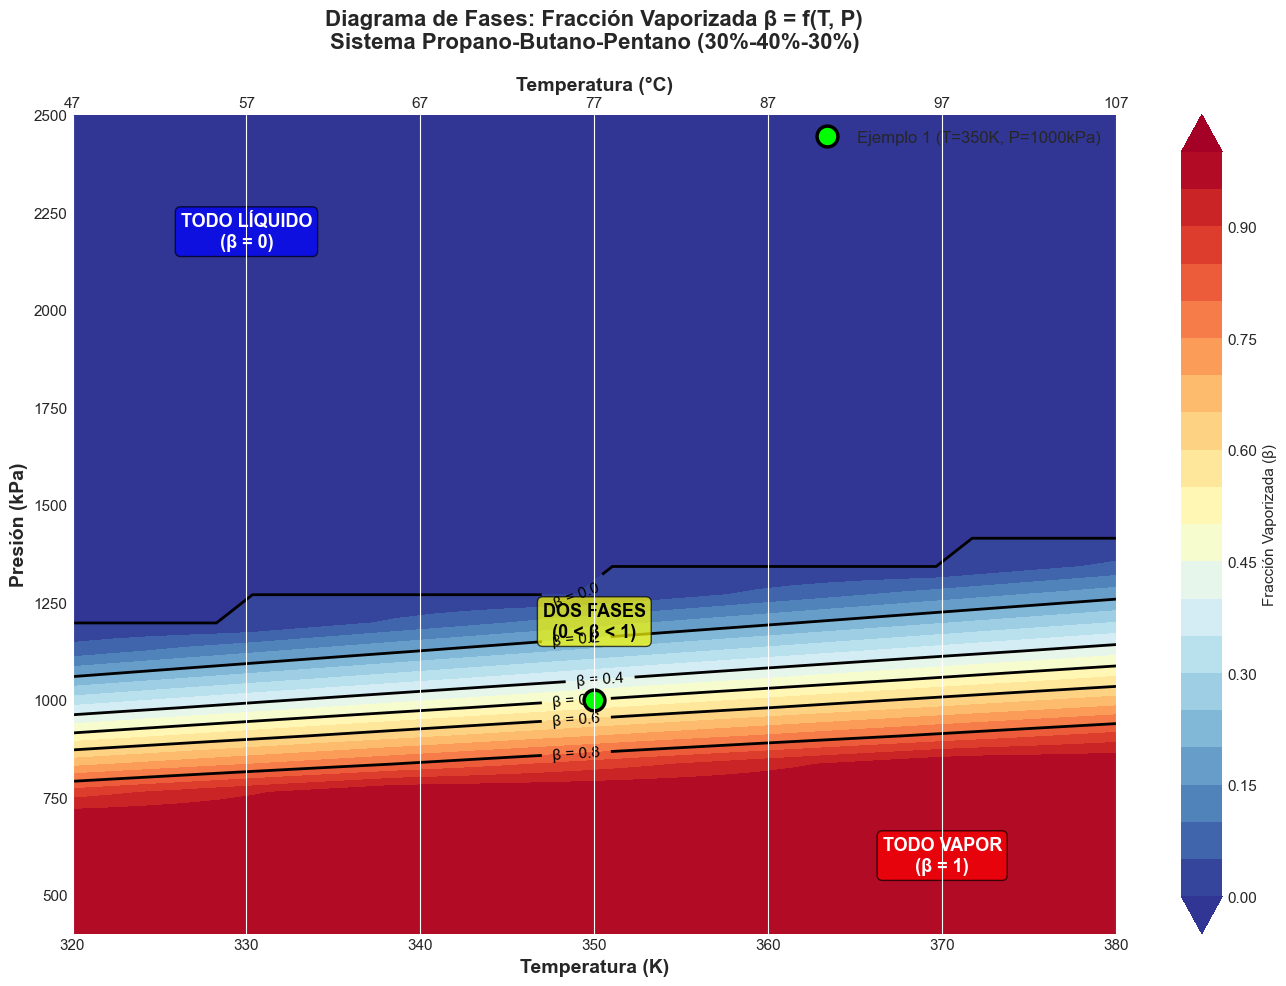


ANÁLISIS DEL DIAGRAMA DE FASES

DISTRIBUCIÓN DE REGIONES:
   Todo líquido (β=0): 525 puntos (58,3%)
   Dos fases (0<β<1):  200 puntos (22,2%)
   Todo vapor (β=1):   175 puntos (19,4%)

INTERPRETACIÓN DEL DIAGRAMA:
   1. REGIÓN AZUL (alta P, cualquier T):
      - Todo permanece líquido
      - Alta presión comprime el vapor
      - Típico en almacenamiento de GLP

   2. REGIÓN VERDE/AMARILLA (P y T intermedias):
      - Coexisten vapor y líquido
      - Región de operación típica para separación
      - β varía gradualmente con T y P

   3. REGIÓN ROJA (baja P, alta T):
      - Todo se vaporiza
      - Condiciones típicas después de válvulas de expansión
      - Puede causar problemas en bombas (cavitación)

APLICACIONES PRÁCTICAS:
   - Diseño: Seleccionar punto de operación en región de dos fases
   - Control: Ajustar T o P para mantener β deseado
   - Seguridad: Evitar cruzar límites de fase inesperadamente
   - Optimización: Buscar gradiente máximo para mejor controlabilidad


In [14]:
# ============================================================================
# DIAGRAMA DE FASES T-P
# ============================================================================

def generar_mapa_fases():
    """
    Crear mapa de β en función de T y P.

    Este diagrama muestra:
    - Regiones de todo líquido (azul oscuro)
    - Regiones de dos fases (verde/amarillo)
    - Regiones de todo vapor (rojo)
    """
    print(es("="*70))
    print(es("CREANDO DIAGRAMA DE FASES (T-P)"))
    print(es("="*70))
    print(es("\n⏳ Calculando... (esto puede tomar 1-2 minutos)"))
    print(es("   Generando malla de 30×30 = 900 puntos"))

    # Definir sistema
    componentes = ['Propano', 'n-Butano', 'n-Pentano']
    z = [0.30, 0.40, 0.30]
    K_ref = [2.5, 1.0, 0.4]  # K de referencia a T=350K, P=1000kPa

    # Crear malla de temperatura y presión
    temps = np.linspace(320, 380, 30)  # 320-380 K
    press = np.linspace(400, 2500, 30)  # 400-2500 kPa

    T_grid, P_grid = np.meshgrid(temps, press)
    beta_grid = np.zeros_like(T_grid)

    # Referencias para ajuste de K
    T_ref = 350
    P_ref = 1000

    # Calcular β para cada combinación (T, P)
    puntos_calculados = 0
    total_puntos = len(temps) * len(press)

    for i, T_val in enumerate(temps):
        for j, P_val in enumerate(press):
            # Ajustar K con T y P usando aproximación simplificada
            # K aumenta con T y disminuye con P
            # K ∝ T/P (aproximación de Clausius-Clapeyron)
            K_temp = [k * (T_val / T_ref) * (P_ref / P_val) for k in K_ref]

            try:
                flash = SeparadorFlashVLE(componentes, z, K_temp, T_val, P_val)
                flash.resolver(verbose=False)
                beta_grid[j, i] = flash.beta
                puntos_calculados += 1
            except:
                beta_grid[j, i] = np.nan

        # Progreso
        if (i+1) % 5 == 0:
            progreso = (i+1) / len(temps) * 100
            print(es(f"   Progreso: {progreso:.0f}% ({puntos_calculados}/{total_puntos} puntos)"))

    print(es(f"\nCálculo completado: {puntos_calculados}/{total_puntos} puntos válidos"))

    # ========================================================================
    # CREAR GRÁFICO
    # ========================================================================
    fig, ax = plt.subplots(figsize=(14, 10))

    # Contour plot con colores
    levels = np.linspace(0, 1, 21)  # 21 niveles de β
    contour = ax.contourf(T_grid, P_grid, beta_grid, levels=levels,
                          cmap='RdYlBu_r', extend='both')
    cbar = plt.colorbar(contour, label='Fracción Vaporizada (β)', ax=ax)
    cbar.ax.tick_params(labelsize=11)

    # Líneas de contorno específicas
    CS = ax.contour(T_grid, P_grid, beta_grid,
                    levels=[0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0],
                    colors='black', linewidths=2, linestyles='solid')
    ax.clabel(CS, inline=True, fontsize=11, fmt='β = %.1f', manual=False)

    # Marcar regiones
    # Región de todo líquido
    ax.text(330, 2200, 'TODO LÍQUIDO\n(β = 0)',
           fontsize=13, fontweight='bold', color='white',
           bbox=dict(boxstyle='round', facecolor='blue', alpha=0.7),
           ha='center', va='center')

    # Región de dos fases
    ax.text(350, 1200, 'DOS FASES\n(0 < β < 1)',
           fontsize=13, fontweight='bold', color='black',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
           ha='center', va='center')

    # Región de todo vapor
    ax.text(370, 600, 'TODO VAPOR\n(β = 1)',
           fontsize=13, fontweight='bold', color='white',
           bbox=dict(boxstyle='round', facecolor='red', alpha=0.7),
           ha='center', va='center')

    # Marcar punto de operación del Ejemplo 1
    ax.plot(350, 1000, 'ko', markersize=15, markerfacecolor='lime',
           markeredgecolor='black', markeredgewidth=2.5,
           label='Ejemplo 1 (T=350K, P=1000kPa)', zorder=10)

    # Configuración de ejes
    ax.set_xlabel('Temperatura (K)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Presión (kPa)', fontsize=14, fontweight='bold')
    ax.set_title('Diagrama de Fases: Fracción Vaporizada β = f(T, P)\n' +
                'Sistema Propano-Butano-Pentano (30%-40%-30%)',
                fontsize=16, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.legend(fontsize=12, loc='upper right')

    # Añadir escala de temperatura en °C en eje superior
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(ax.get_xticks())
    ax2.set_xticklabels([f'{t-273.15:.0f}' for t in ax.get_xticks()])
    ax2.set_xlabel('Temperatura (°C)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ========================================================================
    # ANÁLISIS DEL DIAGRAMA
    # ========================================================================
    print(es("\n" + "="*70))
    print(es("ANÁLISIS DEL DIAGRAMA DE FASES"))
    print(es("="*70))

    # Identificar regiones
    n_todo_liquido = np.sum(beta_grid == 0)
    n_todo_vapor = np.sum(beta_grid == 1)
    n_dos_fases = np.sum((beta_grid > 0) & (beta_grid < 1))
    total = n_todo_liquido + n_todo_vapor + n_dos_fases

    print(es(f"\nDISTRIBUCIÓN DE REGIONES:"))
    print(es(f"   Todo líquido (β=0): {n_todo_liquido} puntos ({n_todo_liquido/total*100:.1f}%)"))
    print(es(f"   Dos fases (0<β<1):  {n_dos_fases} puntos ({n_dos_fases/total*100:.1f}%)"))
    print(es(f"   Todo vapor (β=1):   {n_todo_vapor} puntos ({n_todo_vapor/total*100:.1f}%)"))

    print(es(f"\nINTERPRETACIÓN DEL DIAGRAMA:"))
    print(es(f"   1. REGIÓN AZUL (alta P, cualquier T):"))
    print(es(f"      - Todo permanece líquido"))
    print(es(f"      - Alta presión comprime el vapor"))
    print(es(f"      - Típico en almacenamiento de GLP"))
    print(es(f"\n   2. REGIÓN VERDE/AMARILLA (P y T intermedias):"))
    print(es(f"      - Coexisten vapor y líquido"))
    print(es(f"      - Región de operación típica para separación"))
    print(es(f"      - β varía gradualmente con T y P"))
    print(es(f"\n   3. REGIÓN ROJA (baja P, alta T):"))
    print(es(f"      - Todo se vaporiza"))
    print(es(f"      - Condiciones típicas después de válvulas de expansión"))
    print(es(f"      - Puede causar problemas en bombas (cavitación)"))

    print(es(f"\nAPLICACIONES PRÁCTICAS:"))
    print(es(f"   - Diseño: Seleccionar punto de operación en región de dos fases"))
    print(es(f"   - Control: Ajustar T o P para mantener β deseado"))
    print(es(f"   - Seguridad: Evitar cruzar límites de fase inesperadamente"))
    print(es(f"   - Optimización: Buscar gradiente máximo para mejor controlabilidad"))

# ============================================================================
# EJECUTAR
# ============================================================================
generar_mapa_fases()

---

# 7. Ejercicios

## Ejercicio 1: Mezcla de Cetonas y Aldehídos

Una corriente líquida con la siguiente composición molar es introducida en un tambor flash:
- 30% Acetona
- 45% Metil-etil-cetona (MEK)
- 25% n-Butanal

Las condiciones de operación del tambor son 370 K y 120 kPa.

Constantes de equilibrio a esas condiciones:
- K(Acetona) = 2.2
- K(MEK) = 1.1
- K(n-Butanal) = 0.25

**Determine lo siguiente:**
1. La fracción vaporizada β del sistema
2. Las composiciones molares del vapor y del líquido para cada componente
3. ¿Cuál de los tres compuestos se enriquece preferentemente en la fase vapor? Justifique a partir del valor de K
4. Si el flujo de alimentación es de 250 kmol/h, calcule los flujos de vapor y líquido que abandona el tambor


---

## Ejercicio 0: el método, escrito por usted

Las secciones anteriores le entregaron la clase `SeparadorFlashVLE` ya hecha.
Aquí la va a dejar de lado y va a escribir el núcleo numérico usted, porque es
lo que da nombre al taller. Después la clase le sirve de referencia para
saber si acertó.

**Escriba tres funciones, sin usar la clase:**

1. `f_rr(beta, z, K)` que devuelva el valor de la función de Rachford-Rice.
2. `df_rr(beta, z, K)` que devuelva su derivada respecto de β.
3. `resolver_beta(z, K, tol=1e-10)` que:
   - primero decida si el sistema es de dos fases, con las sumas Σz·K y Σz/K;
   - devuelva 0 o 1 cuando el sistema sea de una sola fase, **sin iterar**;
   - y cuando sea de dos fases resuelva con Newton-Raphson partiendo de β = 0,5.

**Además, dos cosas que la clase del cuaderno no hace y usted sí debe hacer:**

4. Que `resolver_beta` **no dé por convergido** un resultado solo porque el
   paso se hizo pequeño: exija también que |f(β)| sea menor que la tolerancia.
   Explique en una celda de texto por qué las dos condiciones juntas son más
   seguras que cualquiera de las dos sola.
5. Que verifique que la β devuelta está dentro del intervalo físico y que
   Σx = Σy = 1 cuando hay dos fases.

**Valide su implementación** contra los dos ejemplos que el cuaderno ya
resolvió, el de propano-butano-pentano y el de cinco componentes. Reporte la
diferencia entre su β y la de la clase. Si no coinciden hasta la octava cifra,
algo está mal en una de las dos y hay que averiguar en cuál.


In [15]:
# ============================================================
# EJERCICIO 0: escriba aquí su propia implementación
# ============================================================

def f_rr(beta, z, K):
    """Función de Rachford-Rice evaluada en beta."""
    # Su código aquí
    pass


def df_rr(beta, z, K):
    """Derivada de la función de Rachford-Rice respecto de beta."""
    # Su código aquí
    pass


def resolver_beta(z, K, tol=1e-10, max_iter=100):
    """Devuelve la fracción vaporizada. Cero o uno si el sistema es de una fase."""
    # Su código aquí
    pass


# ------------------------------------------------------------
# Validación contra la clase del cuaderno
# ------------------------------------------------------------
# Ejemplo 1 del cuaderno: propano, n-butano, n-pentano
# Ejemplo 2 del cuaderno: los cinco componentes
# Compare su beta con el de la clase e imprima la diferencia.


In [16]:
# ESCRIBE TU SOLUCIÓN AQUÍ

# Datos
componentes_ej1 = ['Acetona', 'MEK', 'n-Butanal']
z_ej1  = [0.30, 0.45, 0.25]
K_ej1  = [2.2, 1.1, 0.25]
T_ej1  = 370   # K
P_ej1  = 120   # kPa
F_ej1  = 250   # kmol/h

# Tu código aquí...


## Ejercicio 2: Fraccionamiento de una Corriente de Nafta

Una corriente de nafta liviana contiene los siguientes hidrocarburos:
- 15% n-Pentano
- 35% n-Hexano
- 30% n-Heptano
- 20% n-Octano

A 395 K y 200 kPa, las constantes de equilibrio son:
- K(n-Pentano)  = 2.40
- K(n-Hexano)   = 1.30
- K(n-Heptano)  = 0.65
- K(n-Octano)   = 0.30

**Actividades a desarrollar:**
1. Resuelva el cálculo flash y obtenga β, x e y para cada componente
2. Compare los resultados con los de un sistema binario formado únicamente por n-Pentano y n-Hexano (usando las mismas condiciones T y P)
3. Analice y discuta cómo la presencia de los componentes más pesados (n-Heptano y n-Octano) modifica la fracción vaporizada con respecto al sistema binario

**Antes de empezar el punto 2:** calcule primero las sumas Σz·K y Σz/K del
binario. El resultado le va a decir algo sobre el estado del sistema que
conviene saber antes de resolver, y que es justamente lo interesante de la
comparación.


In [17]:
# ESCRIBE TU SOLUCIÓN AQUÍ



## Ejercicio 3: Ventana de Operación del Tambor Flash

Considere el sistema Acetona–MEK–n-Butanal del Ejercicio 1, con z = [0.30, 0.45, 0.25] y constantes de equilibrio de referencia K_ref = [2.2, 1.1, 0.25] medidas a las condiciones T_ref = 370 K, P_ref = 120 kPa.

Para este ejercicio, modele la dependencia de las constantes K con respecto a T y P mediante las aproximaciones simplificadas que se indican en cada inciso. Estas aproximaciones son didácticas: en sistemas reales se usan ecuaciones de estado o modelos de actividad.

**Calcule y analice:**

1. ¿A qué valor de presión (kPa) se obtiene una fracción vaporizada β = 0.50? Mantenga T = 370 K constante y use la aproximación K(P) = K_ref · (P_ref / P). Explore el rango [80, 200] kPa.

2. Si la presión se fija en P = 120 kPa, ¿qué temperatura se requiere para lograr β = 0.35? Use la aproximación K(T, P) = K_ref · (T / T_ref) · (P_ref / P). Explore el rango [350, 400] K.

3. Construya una tabla de operación que muestre β para al menos 5 combinaciones diferentes de T (entre 350 K y 400 K) y P (entre 80 kPa y 200 kPa). Identifique la combinación de la grilla que produce la separación más cercana a β = 0.50 y comente brevemente cómo dependen los resultados de la elección de T y P.

In [18]:
# ESCRIBE TU SOLUCIÓN AQUÍ



---

## Rúbrica

| Componente | Puntos | Qué se mira |
|---|---|---|
| Ejercicio 0 · el método escrito por usted | 30 | Las tres funciones correctas, la doble condición de convergencia y la validación contra la clase |
| Ejercicio 1 · cetonas y aldehídos | 20 | β, composiciones, flujos, y cuál componente se enriquece con su justificación |
| Ejercicio 2 · nafta y comparación con el binario | 25 | El flash de cuatro componentes y la lectura correcta del caso límite del binario |
| Ejercicio 3 · ventana de operación | 20 | Las dos búsquedas, la tabla y el comentario sobre la línea de iso-β |
| Presentación del cuaderno | 5 | Ejecutado de arriba abajo, celdas de texto donde se piden, declaración de uso de IA |
| **Total** | **100** | Tolerancia de ±1 % en todo resultado numérico |

**Descuentos:** cuaderno sin ejecutar, no se califica. Respuestas escritas como
comentario dentro de una celda de código en vez de en una celda de texto, 3
puntos por respuesta. Resultados sin unidades, 1 por resultado. Punto decimal
en vez de coma en el informe, 2 puntos.

---


---

## Referencias y Material Complementario

### Libros Recomendados

1. **Seader, J.D., Henley, E.J., & Roper, D.K.** (2011). *Separation Process Principles* (3rd ed.). Wiley.
   - Capítulo 4: Flash and Other Equilibrium Calculations

2. **Smith, J.M., Van Ness, H.C., & Abbott, M.M.** (2005). *Introduction to Chemical Engineering Thermodynamics* (7th ed.). McGraw-Hill.
   - Capítulo 14: Topics in Phase Equilibria

3. **Walas, S.M.** (1985). *Phase Equilibria in Chemical Engineering*. Butterworth-Heinemann.
   - Capítulo 5: Multicomponent Flash Calculations

### Artículos Originales

- **Rachford, H.H., & Rice, J.D.** (1952). "Procedure for Use of Electronic Digital Computers in Calculating Flash Vaporization Hydrocarbon Equilibrium." *Journal of Petroleum Technology*, 4(10), 19-20.

### Recursos en Línea

- LearnChemE.com: Videos educativos sobre separaciones
- NIST WebBook: Propiedades termodinámicas
- Chemical Engineering Resources: Calculadoras en línea

---

## Notas Finales

### Conceptos Clave Aprendidos

1. **Fundamentos teóricos** de la destilación flash multicomponente
2. **Derivación matemática** de la ecuación de Rachford-Rice
3. **Implementación numérica** de algoritmos de solución
4. **Análisis de resultados** y validación física
5. **Sensibilidad paramétrica** del proceso

### Aplicaciones Prácticas

Este método se utiliza en:
- Simuladores de procesos (Aspen HYSYS, PRO/II, UniSim)
- Diseño de separadores gas-líquido
- Operaciones petroleras (separación de hidrocarburos)
- Industria petroquímica (fraccionamiento)
- Producción de gas natural (endulzamiento)

### Próximos Pasos

Para profundizar en el tema:
1. Estudiar modelos termodinámicos complejos (ecuaciones de estado)
2. Implementar flash isotérmico e isentálpico
3. Extender a sistemas reactivos
4. Considerar equilibrio líquido-líquido
5. Optimización de trenes de separación

---

## Contacto y Retroalimentación

Si tiene preguntas, comentarios o sugerencias sobre este notebook, no dude en contactar.

**¡Éxitos!** 

---

*Notebook creado con fines educativos*  
*Última actualización: 2025*